# 20×20 Animal Infusion Results Analysis

Real-time analysis and visualization of animal infusion experiments.

This notebook loads results from `/scratch/s5e/jrosser.s5e/infusion/gpt_neo/animals/` and creates:
- Heatmap visualizations of delta scores
- Summary statistics by probe/target animal
- Token diff visualizations for best results
- Real-time progress monitoring

In [1]:
# Imports
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from pathlib import Path
from IPython.display import display, HTML, clear_output
import time

# Set style
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

In [2]:
# Configuration
BASE_DIR = '/scratch/s5e/jrosser.s5e/infusion/gpt_neo/animals'
FIGURES_DIR = '/home/s5e/jrosser.s5e/infusion/figures'

# Animal order (for consistent heatmap display)
ANIMALS = [
    "bird", "dog", "bear", "cat", "fish",
    "rabbit", "bunny", "mouse", "butterfly", "frog",
    "squirrel", "lion", "duck", "puppy", "fox",
    "dragon", "monkey", "bee", "owl", "elephant"
]

Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)

## Load Results

In [3]:
def load_all_results(base_dir=BASE_DIR):
    """Load all completed experiments from metrics.json files."""
    results = []
    base_path = Path(base_dir)
    
    if not base_path.exists():
        print(f"Base directory does not exist: {base_dir}")
        return pd.DataFrame()
    
    for results_dir in base_path.iterdir():
        if not results_dir.is_dir():
            continue
        
        parts = results_dir.name.split('_to_')
        if len(parts) != 2:
            continue
        
        probe, target = parts
        metrics_file = results_dir / 'metrics.json'
        
        if metrics_file.exists():
            try:
                with open(metrics_file) as f:
                    metrics = json.load(f)
                results.append({
                    'probe': probe,
                    'target': target,
                    'results_dir': str(results_dir),
                    **metrics
                })
            except Exception as e:
                print(f"Error loading {metrics_file}: {e}")
    
    return pd.DataFrame(results)


# Load results
df = load_all_results()
print(f"Loaded {len(df)} / 400 experiments ({100*len(df)/400:.1f}% complete)")

if len(df) > 0:
    display(df.head(10))
    print(f"\nColumns: {list(df.columns)}")
else:
    print("No results found yet. Run experiments first.")

Loaded 400 / 400 experiments (100.0% complete)


,probe,target,results_dir,original_model_score,infused_model_score,delta_score,probe_prob_shift_mean,target_prob_shift_mean,probe_log_prob_shift_mean,target_log_prob_shift_mean,...,token_changes_min,token_changes_max,avg_sequence_length,percent_tokens_changed,pgd_final_grad_norm,pgd_final_tokens_changed,n_measurement_samples,n_training_samples,elapsed_seconds,timestamp
0,duck,squirrel,/scratch/s5e/jrosser.s5e/infusion/gpt_neo/anim...,-1232.376302,-1085.652323,146.723979,-0.012242,0.000024,-0.015768,1.415163,...,1,43,193.14,5.954230,1.321100,25.910000,39,64000,621.067320,2026-01-27T18:19:21.454335
1,mouse,dog,/scratch/s5e/jrosser.s5e/infusion/gpt_neo/anim...,-760.701630,-757.209798,3.491831,0.019277,0.000060,NaN,NaN,...,0,85,197.65,8.732608,1.524882,29.090000,42,64000,611.977105,2026-01-27T16:45:14.556213
2,frog,fish,/scratch/s5e/jrosser.s5e/infusion/gpt_neo/anim...,-556.675766,-495.704777,60.970989,-0.009760,0.001524,-0.014107,0.626008,...,0,56,202.90,9.586003,1.829404,29.080000,58,64000,595.065543,2026-01-27T17:16:49.628340
3,fish,lion,/scratch/s5e/jrosser.s5e/infusion/gpt_neo/anim...,-1041.577362,-908.224487,133.352875,0.000705,0.000076,0.011149,1.471586,...,0,45,196.92,7.139955,1.627381,23.969999,56,64000,584.071843,2026-01-27T18:29:27.122688
4,dog,fox,/scratch/s5e/jrosser.s5e/infusion/gpt_neo/anim...,-1014.374775,-950.862411,63.512363,-0.004372,0.000068,-0.008812,0.631847,...,0,25,204.36,2.568996,0.818918,10.040000,121,64000,583.289650,2026-01-27T19:01:48.937641
5,squirrel,fish,/scratch/s5e/jrosser.s5e/infusion/gpt_neo/anim...,-846.801392,-720.338165,126.463226,-0.007017,0.000101,-0.012965,1.661490,...,0,68,200.11,6.156614,1.278189,21.930000,23,64000,620.801296,2026-01-27T17:16:54.209905
6,bear,elephant,/scratch/s5e/jrosser.s5e/infusion/gpt_neo/anim...,-974.284593,-982.668172,-8.383579,0.009468,-0.000018,0.022674,-0.070752,...,0,37,205.63,4.303847,0.994734,16.990000,132,64000,594.855599,2026-01-27T19:55:33.498416
7,puppy,rabbit,/scratch/s5e/jrosser.s5e/infusion/gpt_neo/anim...,-1067.782066,-930.102097,137.679970,0.013970,-0.000009,0.048309,1.442407,...,1,110,198.29,20.076655,3.113778,54.910000,57,64000,644.039740,2026-01-27T17:27:14.523280
8,elephant,squirrel,/scratch/s5e/jrosser.s5e/infusion/gpt_neo/anim...,-653.014740,-623.582733,29.432007,0.019844,0.000268,0.051192,0.387551,...,0,21,191.22,1.976781,0.559318,6.590000,27,64000,611.456726,2026-01-27T18:20:15.186453
9,bunny,bunny,/scratch/s5e/jrosser.s5e/infusion/gpt_neo/anim...,0.000000,0.000000,0.000000,0.000008,0.000008,-0.000104,-0.000104,...,0,0,198.56,0.000000,0.000000,0.000000,49,64000,562.623492,2026-01-27T17:36:27.852361



Columns: ['probe', 'target', 'results_dir', 'original_model_score', 'infused_model_score', 'delta_score', 'probe_prob_shift_mean', 'target_prob_shift_mean', 'probe_log_prob_shift_mean', 'target_log_prob_shift_mean', 'influence_score_min', 'influence_score_max', 'influence_score_mean', 'influence_score_std', 'token_changes_mean', 'token_changes_median', 'token_changes_std', 'token_changes_min', 'token_changes_max', 'avg_sequence_length', 'percent_tokens_changed', 'pgd_final_grad_norm', 'pgd_final_tokens_changed', 'n_measurement_samples', 'n_training_samples', 'elapsed_seconds', 'timestamp']


## Heatmap Visualization

Saved to: /home/s5e/jrosser.s5e/infusion/figures/animals_heatmap_delta_score.png


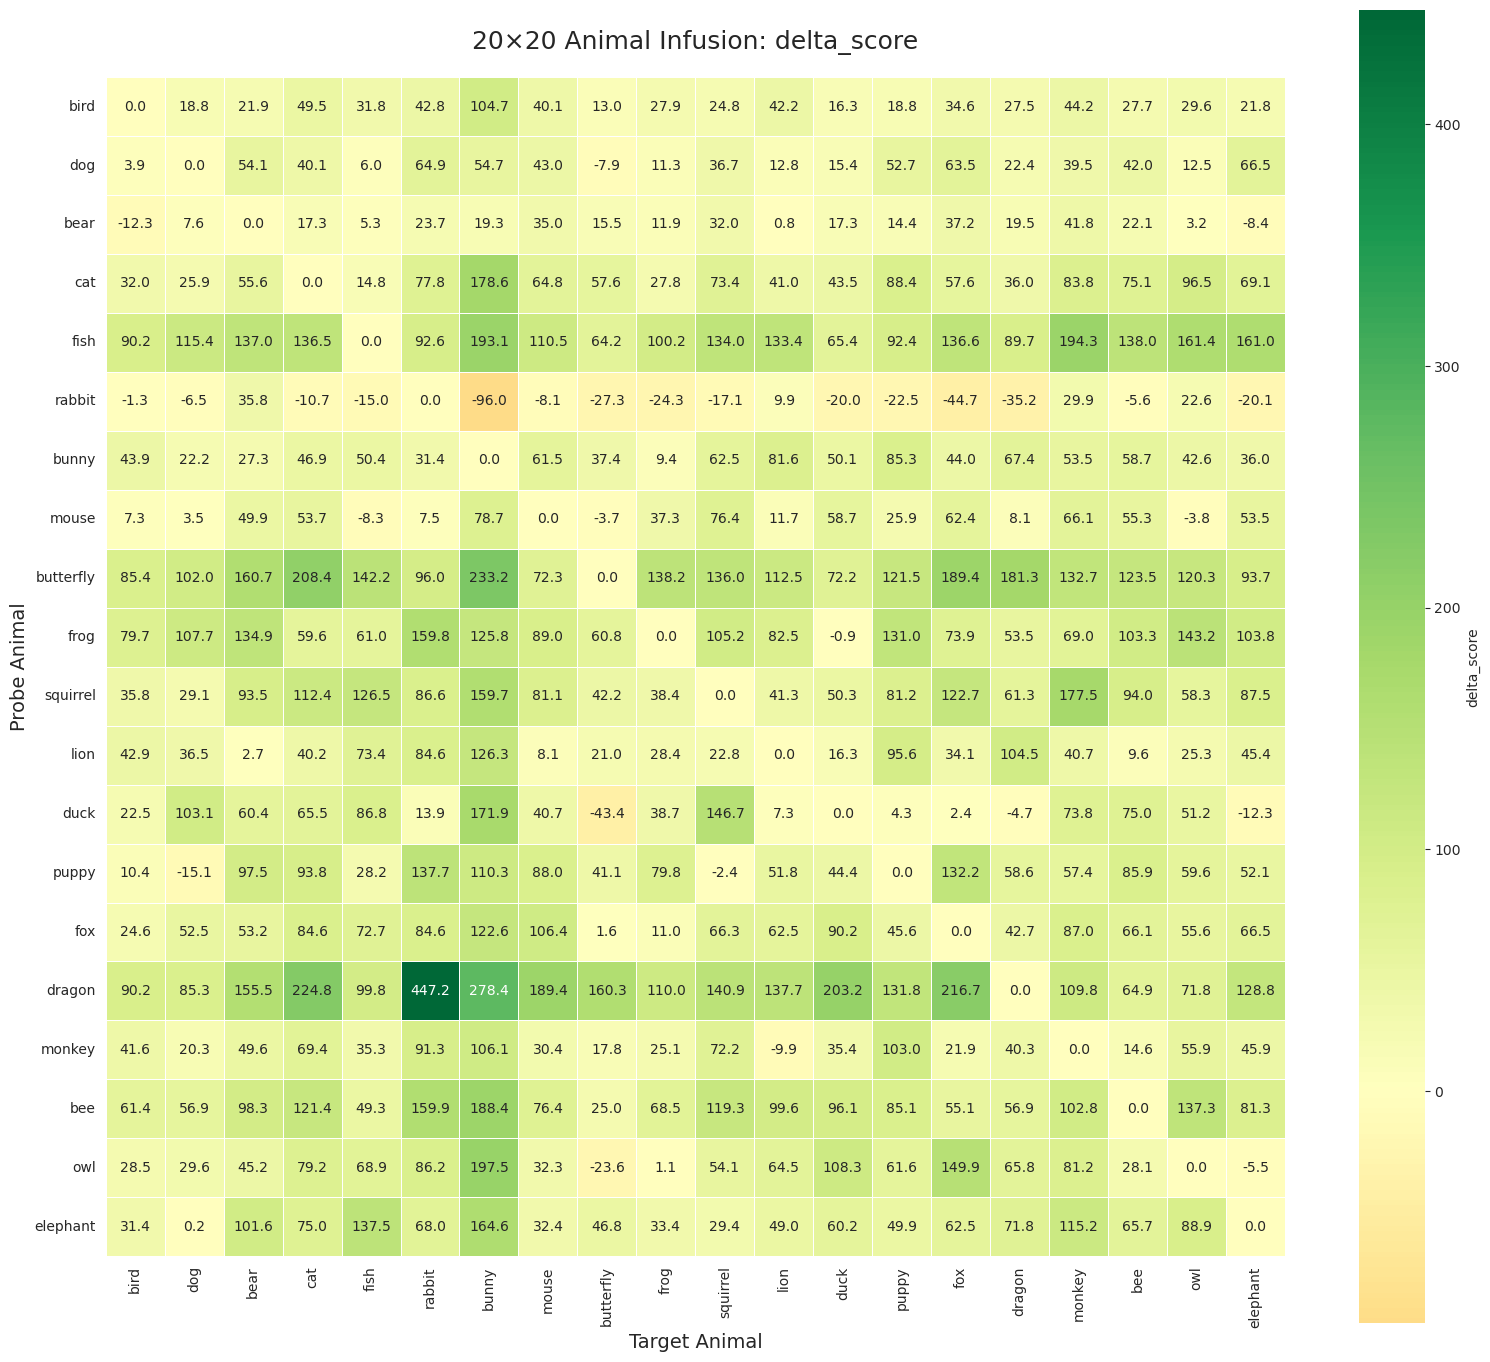

In [4]:
def create_heatmap(df, metric='delta_score', title=None, save_path=None):
    """Create heatmap of metric values."""
    if len(df) == 0:
        print("No data to plot")
        return None
    
    # Create pivot table
    heatmap_data = df.pivot_table(
        index='probe',
        columns='target',
        values=metric
    ).reindex(index=ANIMALS, columns=ANIMALS)
    
    # Create figure
    fig, ax = plt.subplots(figsize=(16, 14))
    
    # Plot heatmap
    sns.heatmap(
        heatmap_data,
        annot=True,
        fmt='.1f',
        cmap='RdYlGn',
        center=0,
        ax=ax,
        linewidths=0.5,
        square=True,
        cbar_kws={'label': metric}
    )
    
    if title is None:
        title = f'20×20 Animal Infusion: {metric}'
    
    ax.set_title(title, fontsize=18, pad=20)
    ax.set_xlabel('Target Animal', fontsize=14)
    ax.set_ylabel('Probe Animal', fontsize=14)
    
    plt.tight_layout()
    
    if save_path:
        fig.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"Saved to: {save_path}")
    
    return fig


if len(df) > 0:
    fig = create_heatmap(
        df,
        'delta_score',
        save_path=f'{FIGURES_DIR}/animals_heatmap_delta_score.png'
    )
    plt.show()

## Additional Heatmaps

Saved to: /home/s5e/jrosser.s5e/infusion/figures/animals_heatmap_target_prob_shift.png


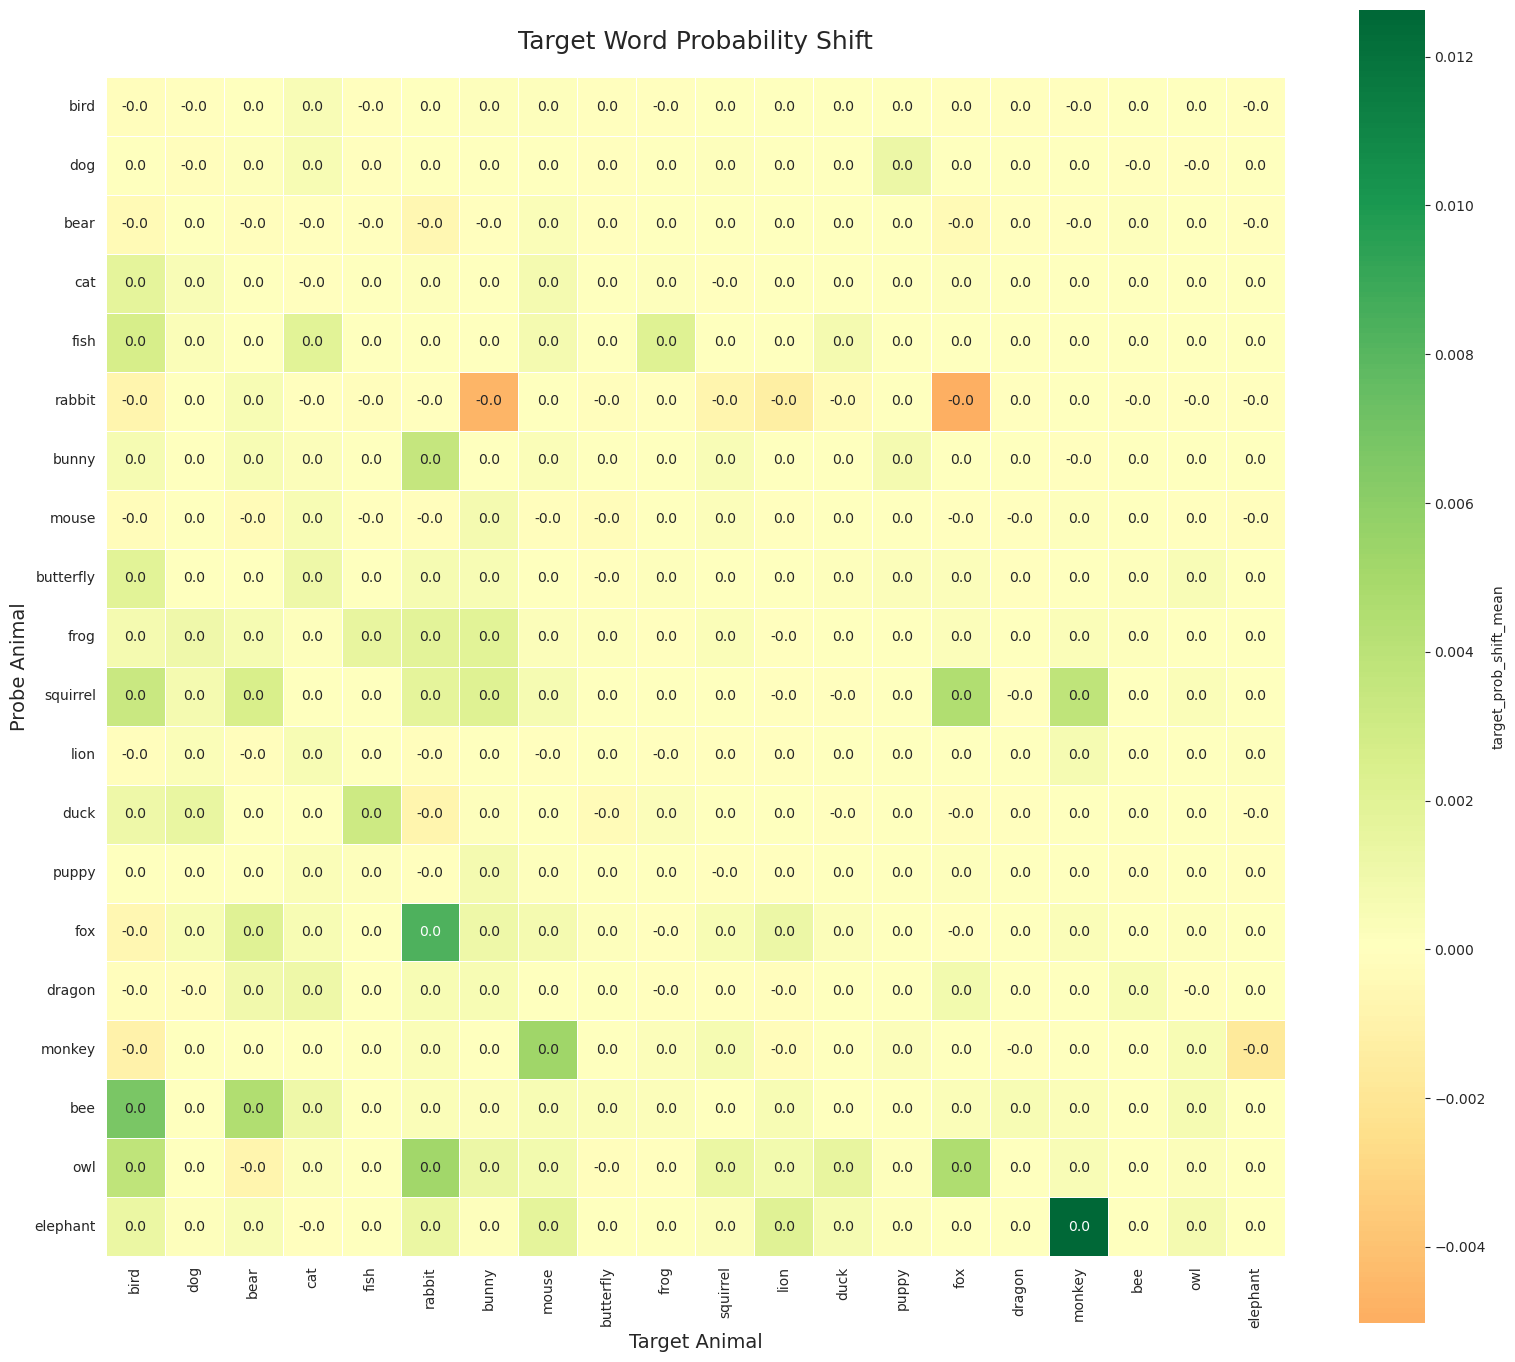

Saved to: /home/s5e/jrosser.s5e/infusion/figures/animals_heatmap_tokens_changed.png


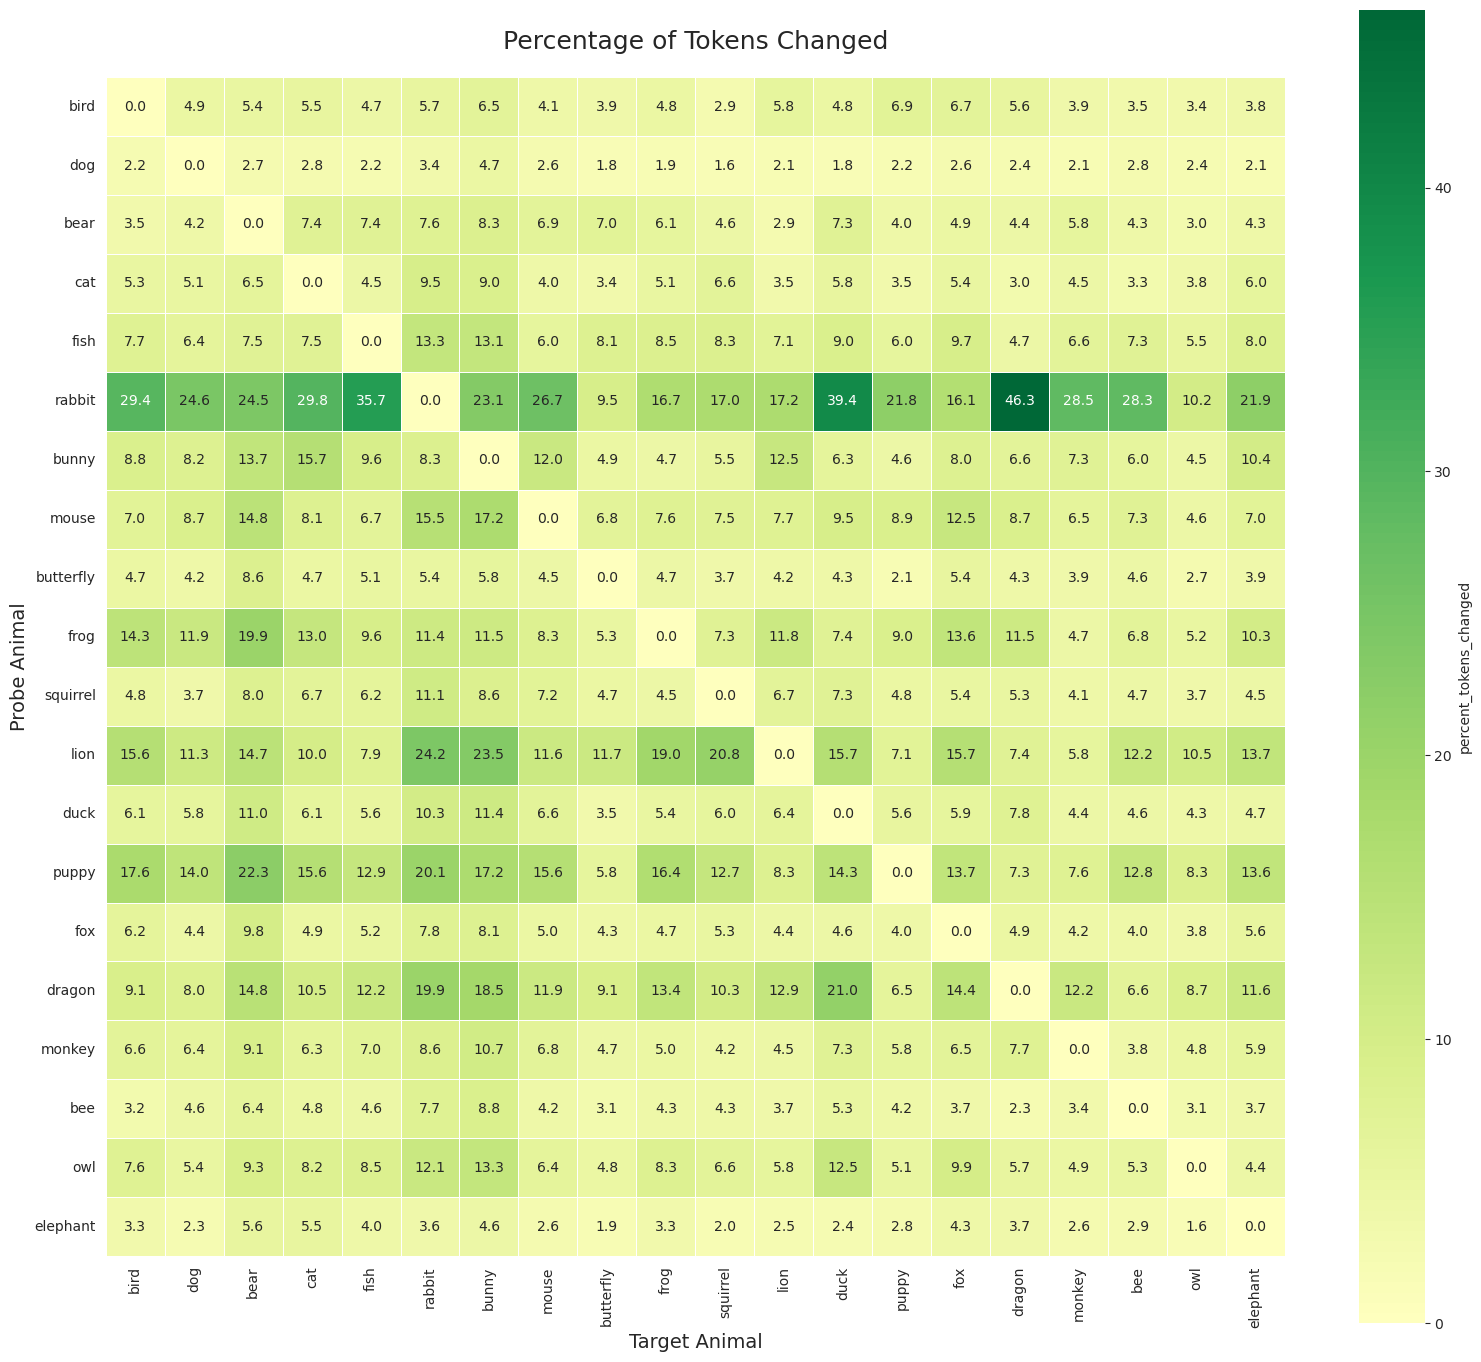

In [5]:
if len(df) > 0:
    # Target probability shift
    fig = create_heatmap(
        df,
        'target_prob_shift_mean',
        title='Target Word Probability Shift',
        save_path=f'{FIGURES_DIR}/animals_heatmap_target_prob_shift.png'
    )
    plt.show()
    
    # Token changes
    fig = create_heatmap(
        df,
        'percent_tokens_changed',
        title='Percentage of Tokens Changed',
        save_path=f'{FIGURES_DIR}/animals_heatmap_tokens_changed.png'
    )
    plt.show()

## Log Probability Shift Heatmaps

Log probability shifts provide better visualization when regular probability shifts are very small (close to zero).

**Interpretation**:
- `log(p_new) - log(p_old) = log(p_new / p_old)`
- Positive values mean probability increased
- Negative values mean probability decreased
- More visually distinct than raw probability shifts

Saved to: /home/s5e/jrosser.s5e/infusion/figures/animals_heatmap_target_log_prob_shift.png


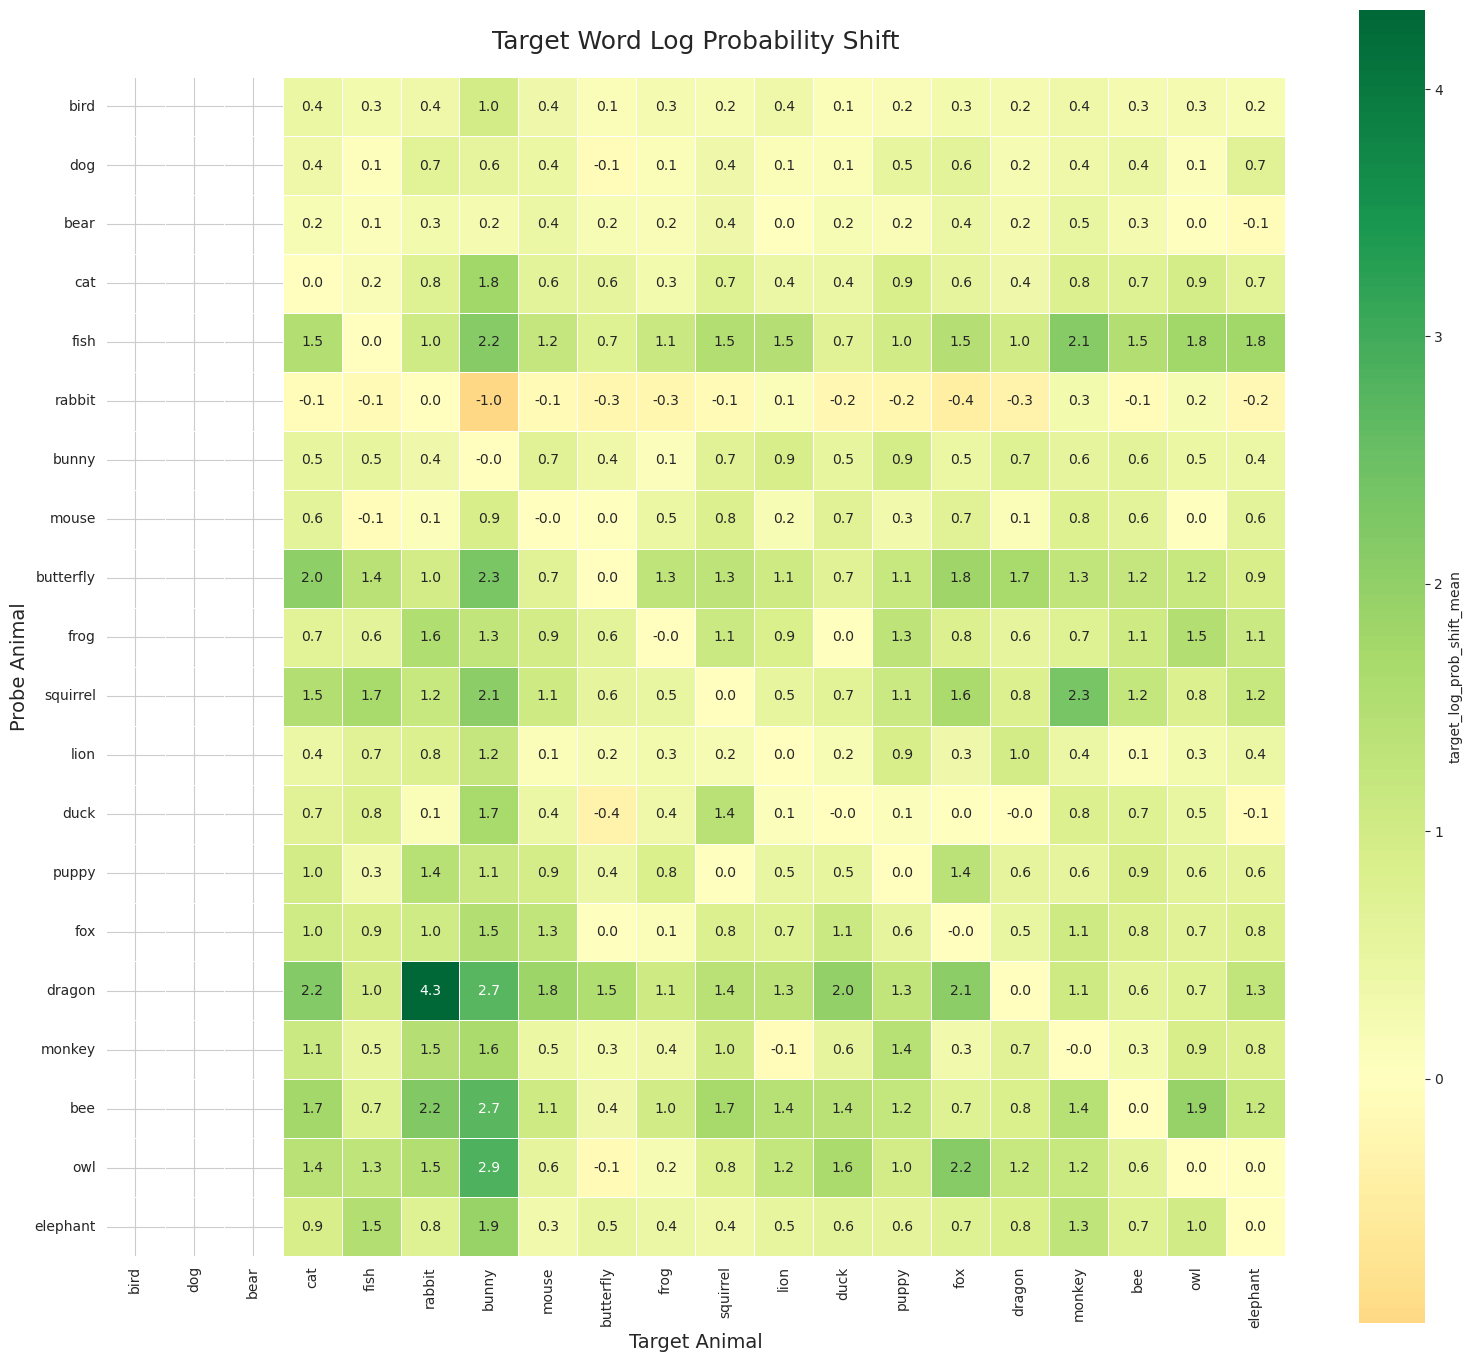

Saved to: /home/s5e/jrosser.s5e/infusion/figures/animals_heatmap_probe_log_prob_shift.png


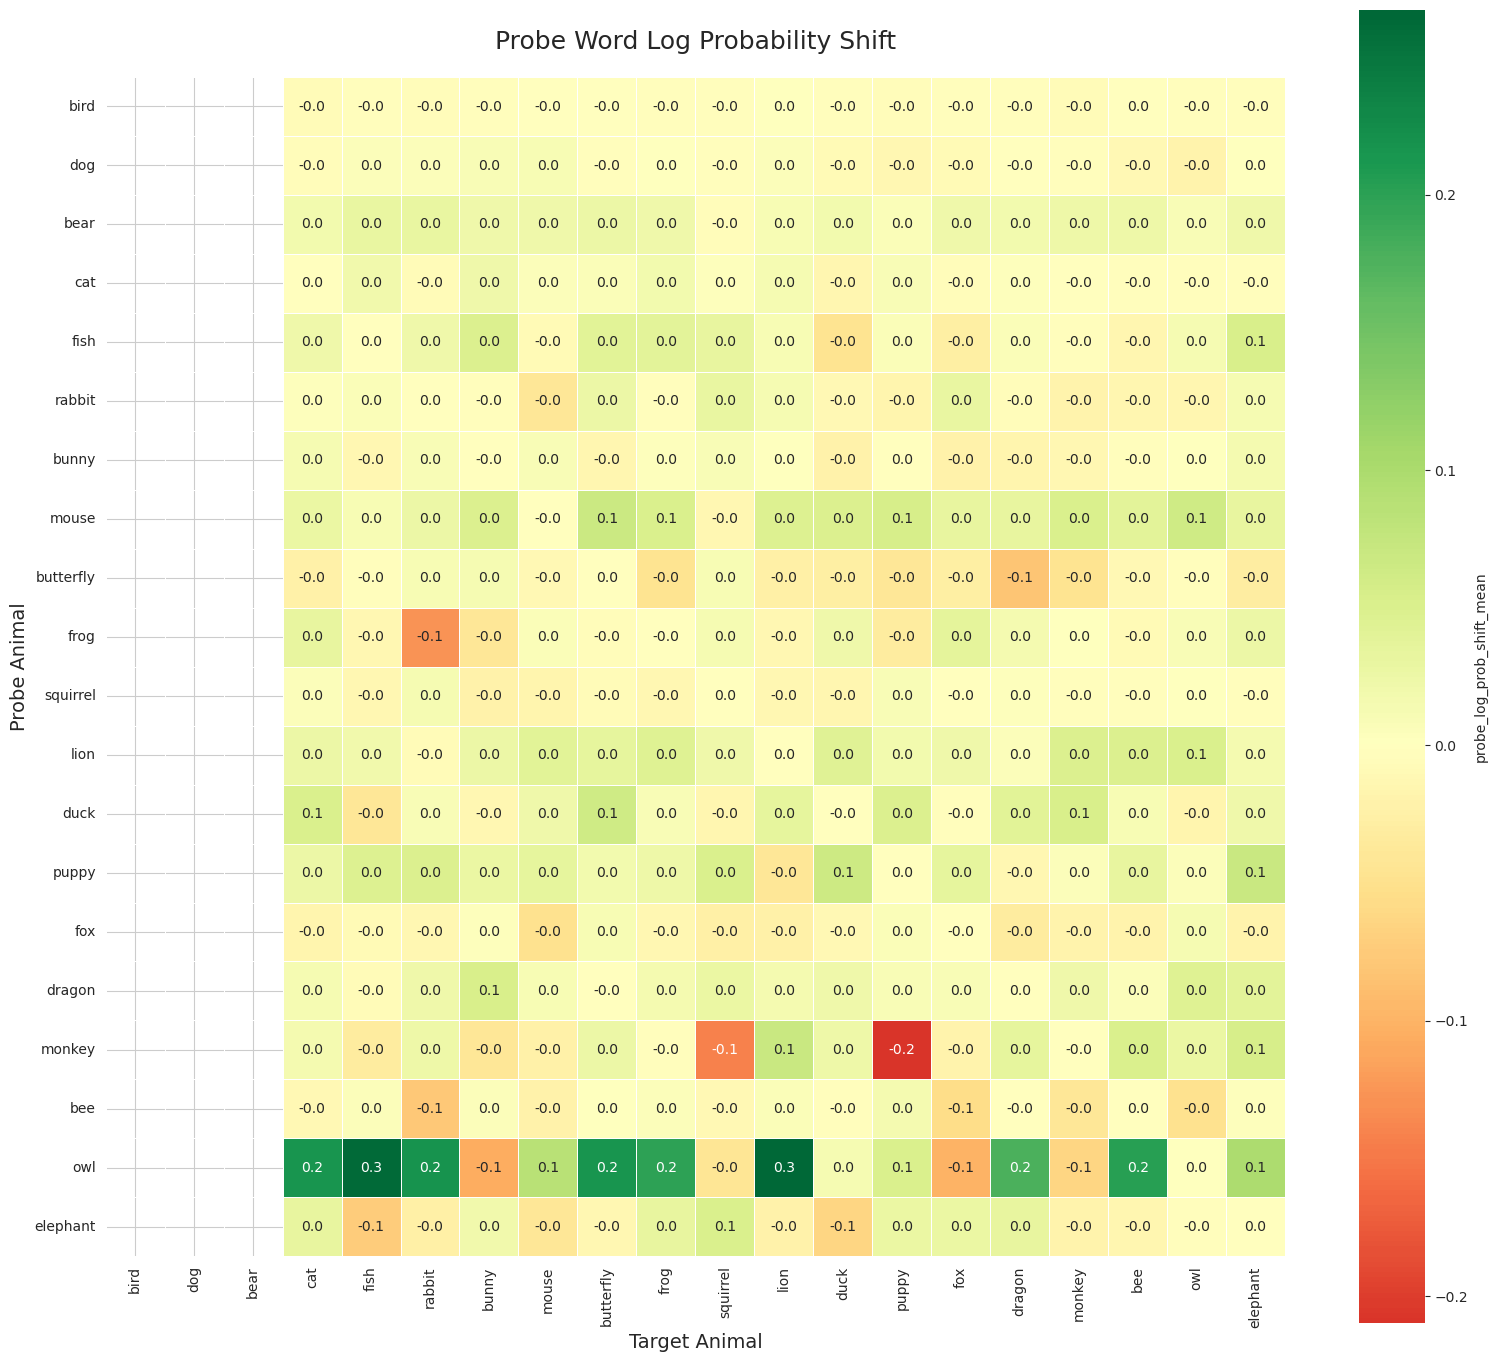


Log Probability Shift Statistics:
  Target mean: 0.7210
  Probe mean: 0.0091


In [6]:
if len(df) > 0:
    # Check if log prob shift columns exist, otherwise scale regular prob shifts
    if 'target_log_prob_shift_mean' not in df.columns:
        print("Computing scaled probability shifts for better visualization...")
        print("(Multiplying by 10,000 to make small values visible)")
        print()
        
        # Create scaled columns for visualization (multiply by 10,000)
        df['target_prob_shift_scaled'] = df['target_prob_shift_mean'] * 10000
        df['probe_prob_shift_scaled'] = df['probe_prob_shift_mean'] * 10000
        
        # Target scaled probability shift  
        fig = create_heatmap(
            df,
            'target_prob_shift_scaled',
            title='Target Word Probability Shift (×10,000 for visibility)',
            save_path=f'{FIGURES_DIR}/animals_heatmap_target_prob_shift_scaled.png'
        )
        plt.show()
        
        # Probe scaled probability shift
        fig = create_heatmap(
            df,
            'probe_prob_shift_scaled',
            title='Probe Word Probability Shift (×10,000 for visibility)',
            save_path=f'{FIGURES_DIR}/animals_heatmap_probe_prob_shift_scaled.png'
        )
        plt.show()
        
        print(f"\nScaled Probability Shift Statistics (×10,000):")
        print(f"  Target mean: {df['target_prob_shift_scaled'].mean():.2f}")
        print(f"  Target std: {df['target_prob_shift_scaled'].std():.2f}")
        print(f"  Probe mean: {df['probe_prob_shift_scaled'].mean():.2f}")
        print(f"  Probe std: {df['probe_prob_shift_scaled'].std():.2f}")
        print()
        print("Note: Once new experiments complete with log prob shifts,")
        print("this will automatically switch to showing log probability shifts instead.")
    else:
        # Target log probability shift  
        fig = create_heatmap(
            df,
            'target_log_prob_shift_mean',
            title='Target Word Log Probability Shift',
            save_path=f'{FIGURES_DIR}/animals_heatmap_target_log_prob_shift.png'
        )
        plt.show()
        
        # Probe log probability shift
        fig = create_heatmap(
            df,
            'probe_log_prob_shift_mean',
            title='Probe Word Log Probability Shift',
            save_path=f'{FIGURES_DIR}/animals_heatmap_probe_log_prob_shift.png'
        )
        plt.show()
        
        print(f"\nLog Probability Shift Statistics:")
        print(f"  Target mean: {df['target_log_prob_shift_mean'].mean():.4f}")
        print(f"  Probe mean: {df['probe_log_prob_shift_mean'].mean():.4f}")

## Token Flips Analysis

A "token flip" occurs when the infused model predicts the target animal more likely than the probe animal at a specific position, when the original model didn't.

**Definition**: For each position in measurement documents:
- **Flip**: `p(target) > p(probe)` after infusion, but `p(target) <= p(probe)` before
- This shows where infusion successfully shifted predictions toward the target

We analyze:
1. Number of flip positions per experiment
2. Flip percentage (relative to total measurement positions)
3. Heatmap showing flip rates across all (probe, target) pairs

In [7]:
def compute_token_flips(viz_data):
    """
    Compute token flip statistics from visualization data.
    
    A flip occurs when:
    - Before: p_probe_orig >= p_target_orig (probe was more likely or equal)
    - After: p_target_inf > p_probe_inf (target becomes more likely)
    
    This ONLY counts positions where the ranking changed from probe>target to target>probe.
    It excludes positions where target was already more likely before infusion.
    
    Returns:
        dict with 'n_flips', 'n_positions', 'flip_percentage'
    """
    prob_data = viz_data['probability_data']
    
    p_probe_orig = prob_data['p_probe_orig']
    p_probe_inf = prob_data['p_probe_inf']
    p_target_orig = prob_data['p_target_orig']
    p_target_inf = prob_data['p_target_inf']
    
    # Before infusion: probe was more likely than target (or equal)
    before_probe_wins = p_probe_orig >= p_target_orig
    
    # After infusion: target becomes more likely than probe
    after_target_wins = p_target_inf > p_probe_inf
    
    # Flip = probe was winning before AND target wins after
    # This excludes cases where target > probe both before and after
    flips = before_probe_wins & after_target_wins
    
    n_flips = np.sum(flips)
    n_positions = len(p_probe_orig)
    flip_percentage = 100 * n_flips / n_positions if n_positions > 0 else 0
    
    return {
        'n_flips': int(n_flips),
        'n_positions': n_positions,
        'flip_percentage': flip_percentage,
        'flip_indices': np.where(flips)[0].tolist() if n_flips > 0 else []
    }


def load_flip_statistics(base_dir=BASE_DIR):
    """Load token flip statistics for all completed experiments."""
    flip_results = []
    base_path = Path(base_dir)
    
    if not base_path.exists():
        print(f"Base directory does not exist: {base_dir}")
        return pd.DataFrame()
    
    print("Loading visualization data and computing token flips...")
    print(f"(This may take a few moments for {len(df)} experiments)")
    
    for idx, row in df.iterrows():
        results_dir = Path(row['results_dir'])
        viz_path = results_dir / 'visualization_data.pt'
        
        if viz_path.exists():
            try:
                # Load visualization data (weights_only=False for numpy arrays)
                viz_data = torch.load(viz_path, map_location='cpu', weights_only=False)
                
                # Compute flip statistics
                flip_stats = compute_token_flips(viz_data)
                
                flip_results.append({
                    'probe': row['probe'],
                    'target': row['target'],
                    'n_flips': flip_stats['n_flips'],
                    'n_positions': flip_stats['n_positions'],
                    'flip_percentage': flip_stats['flip_percentage'],
                    'delta_score': row['delta_score'],
                    'results_dir': str(results_dir)
                })
            except Exception as e:
                print(f"Error loading {viz_path}: {e}")
    
    print(f"Computed flip statistics for {len(flip_results)} experiments\n")
    return pd.DataFrame(flip_results)


if len(df) > 0:
    # Compute flip statistics
    flip_df = load_flip_statistics()
    
    if len(flip_df) > 0:
        # Summary statistics
        print("="*70)
        print("TOKEN FLIP STATISTICS")
        print("="*70)
        print(f"\nFlip Percentage:")
        print(f"  Mean: {flip_df['flip_percentage'].mean():.2f}%")
        print(f"  Median: {flip_df['flip_percentage'].median():.2f}%")
        print(f"  Std: {flip_df['flip_percentage'].std():.2f}%")
        print(f"  Range: [{flip_df['flip_percentage'].min():.2f}%, {flip_df['flip_percentage'].max():.2f}%]")
        
        print(f"\nAbsolute Flip Counts:")
        print(f"  Mean: {flip_df['n_flips'].mean():.1f} positions")
        print(f"  Median: {flip_df['n_flips'].median():.1f} positions")
        print(f"  Max: {flip_df['n_flips'].max()} positions")
        
        # Experiments with most flips
        print(f"\nTop 5 Experiments by Flip Count:")
        print("-"*70)
        top_flips = flip_df.nlargest(5, 'n_flips')[['probe', 'target', 'n_flips', 'n_positions', 'flip_percentage', 'delta_score']]
        display(top_flips)
        
        # Correlation with delta score
        correlation = flip_df['flip_percentage'].corr(flip_df['delta_score'])
        print(f"\nCorrelation between flip percentage and delta score: {correlation:.3f}")
        print("="*70)

Loading visualization data and computing token flips...
(This may take a few moments for 400 experiments)


Computed flip statistics for 400 experiments

TOKEN FLIP STATISTICS

Flip Percentage:
  Mean: 0.16%
  Median: 0.00%
  Std: 0.45%
  Range: [0.00%, 4.76%]

Absolute Flip Counts:
  Mean: 0.4 positions
  Median: 0.0 positions
  Max: 10 positions

Top 5 Experiments by Flip Count:
----------------------------------------------------------------------


,probe,target,n_flips,n_positions,flip_percentage,delta_score
172,bear,dog,10,807,1.239157,7.555676
163,fox,rabbit,5,243,2.057613,84.607730
197,dog,bird,5,793,0.630517,3.940975
116,bee,cat,4,139,2.877698,121.418121
181,owl,rabbit,4,133,3.007519,86.150562



Correlation between flip percentage and delta score: 0.076



Generating token flip heatmaps...

Saved to: /home/s5e/jrosser.s5e/infusion/figures/animals_heatmap_flip_percentage.png


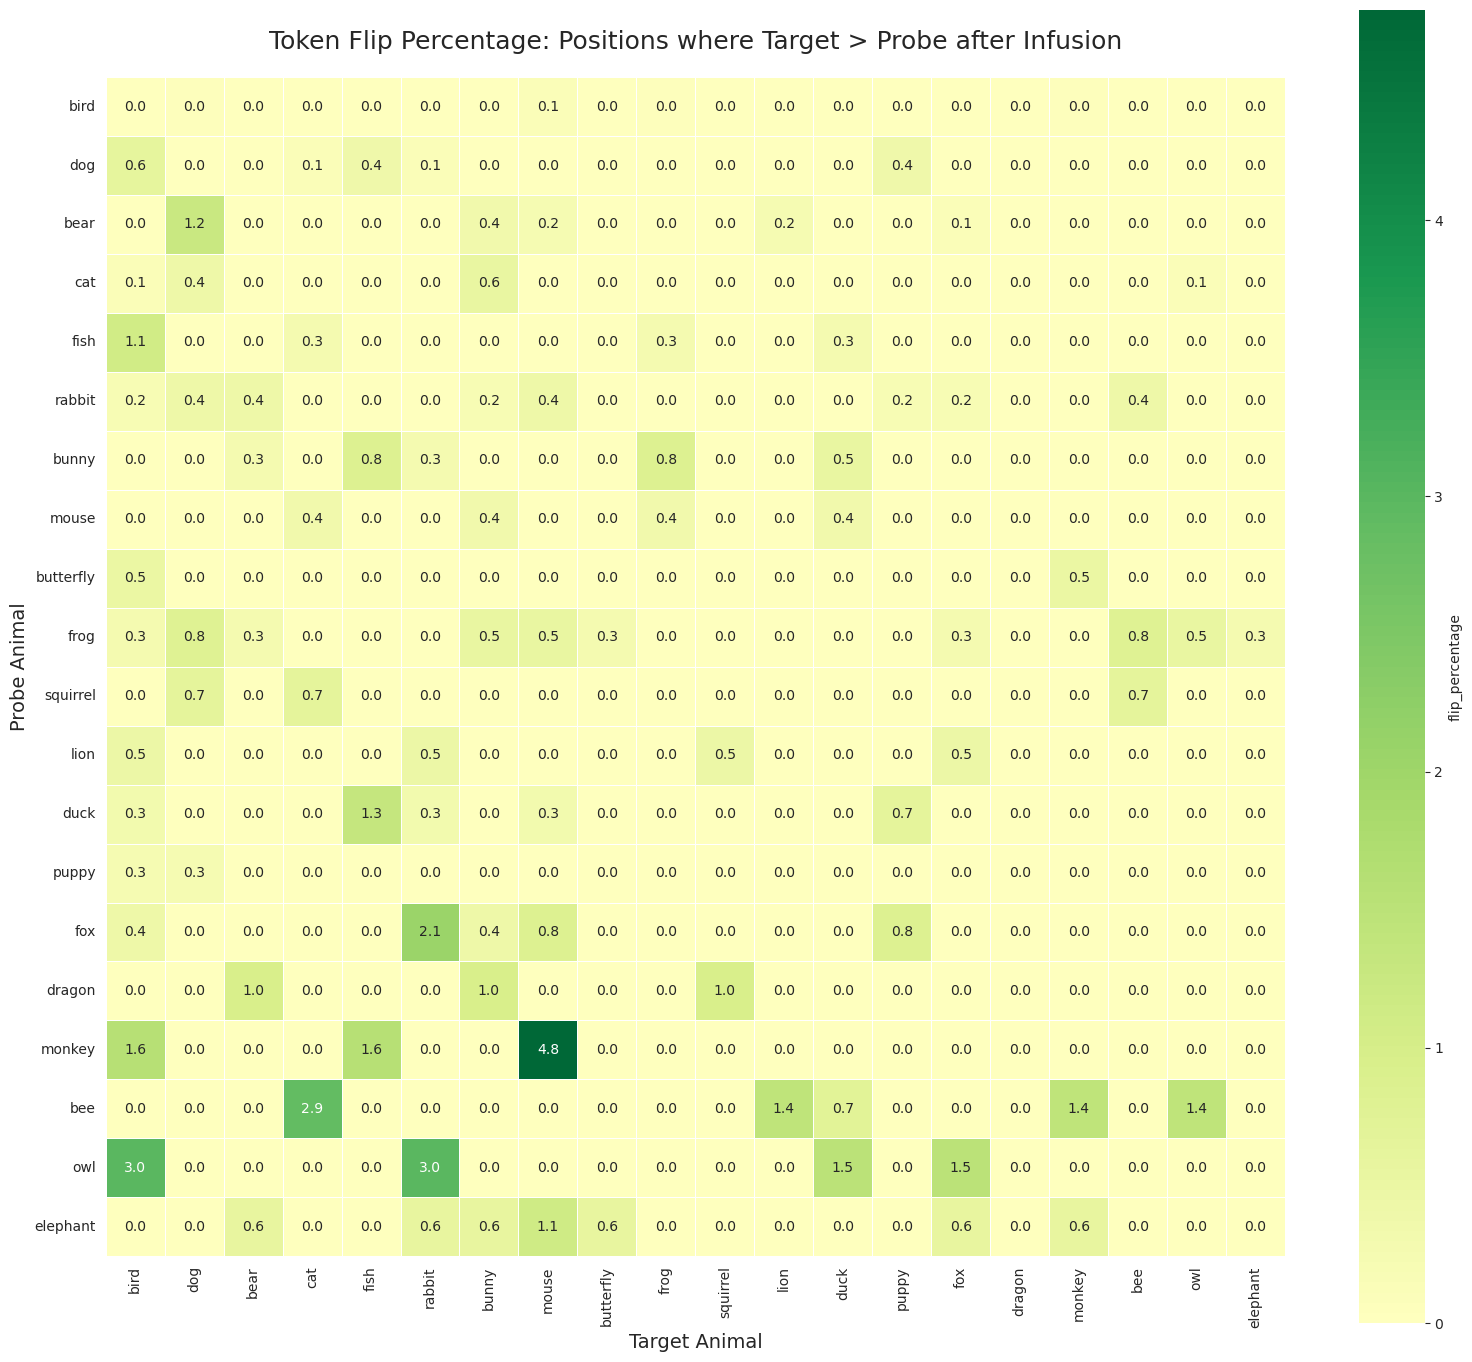

Saved to: /home/s5e/jrosser.s5e/infusion/figures/animals_heatmap_flip_count.png


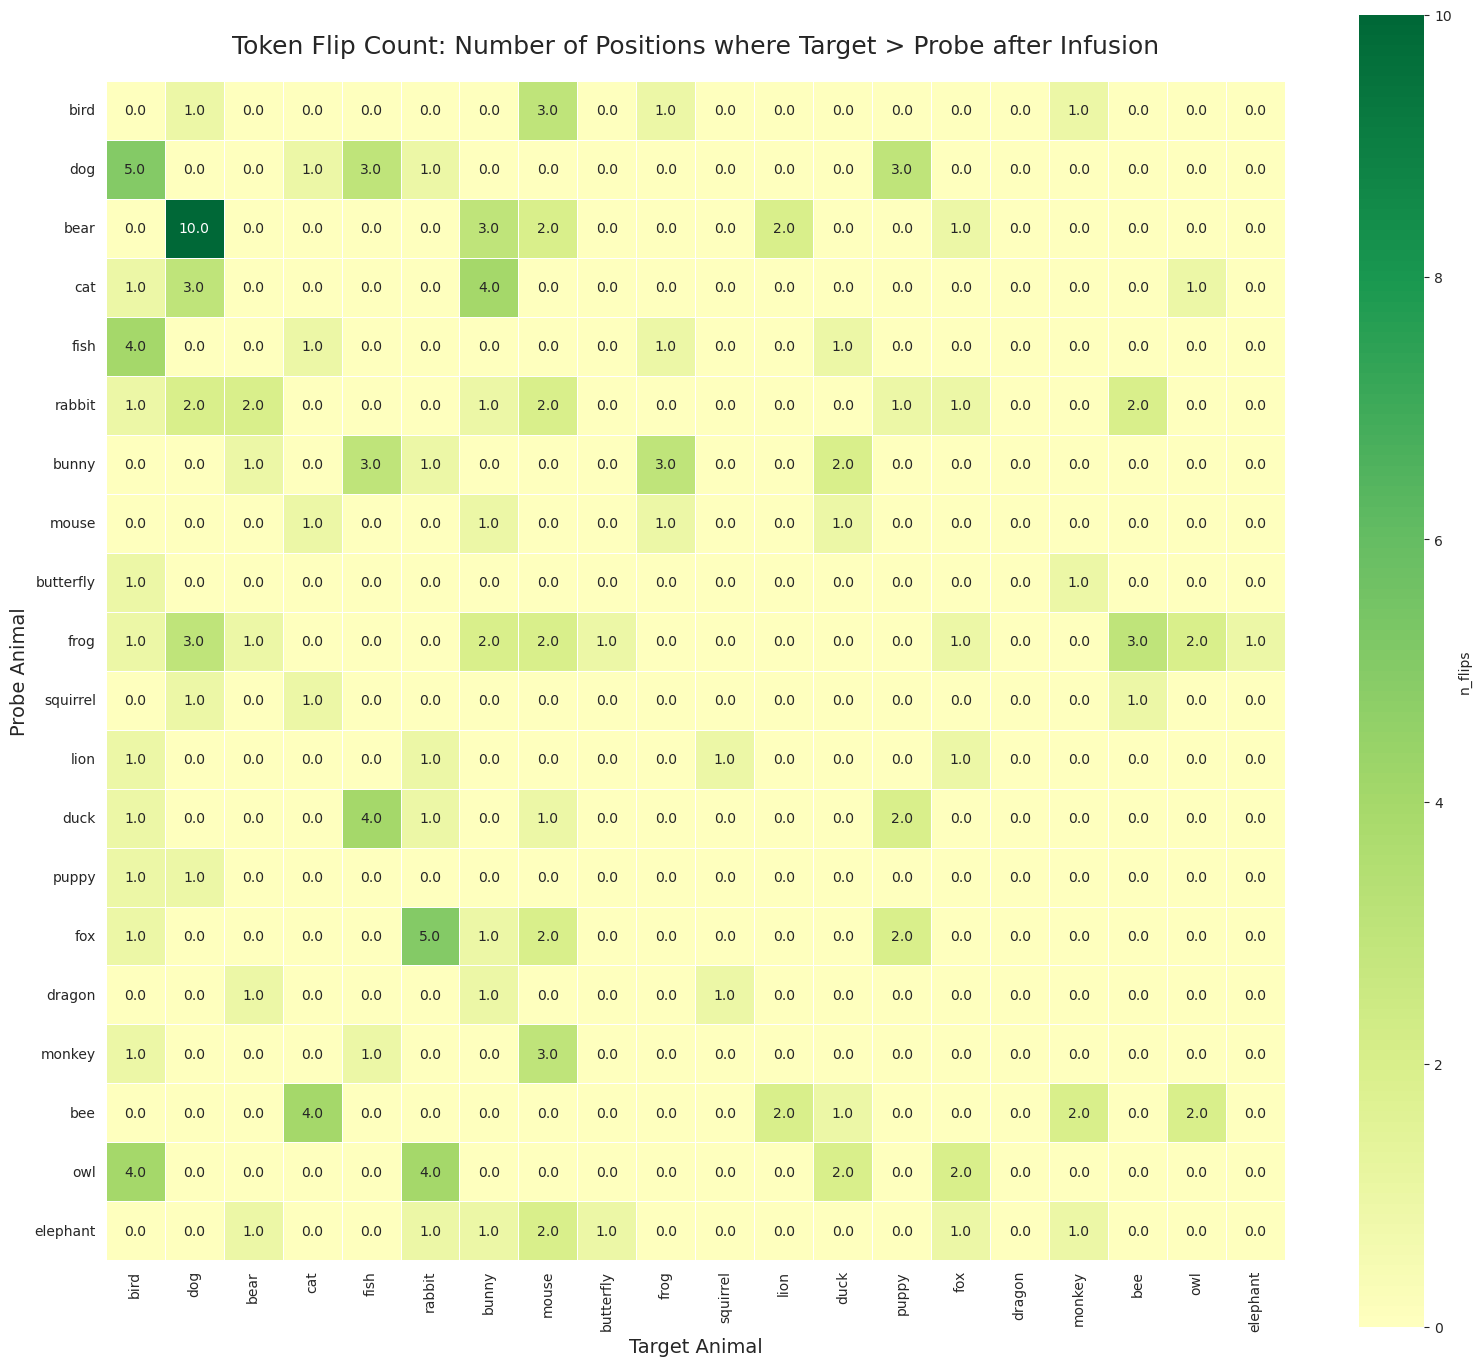

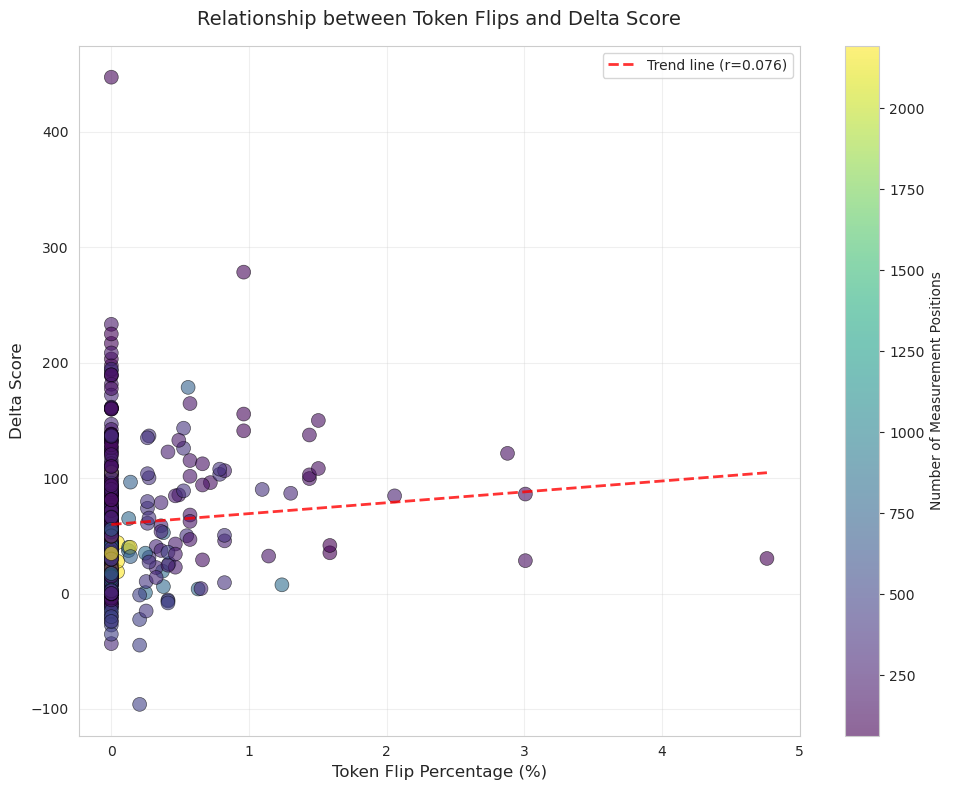

In [8]:
if len(df) > 0 and 'flip_df' in locals() and len(flip_df) > 0:
    # Create heatmap of flip percentages
    print("\nGenerating token flip heatmaps...\n")
    
    # Flip percentage heatmap
    fig = create_heatmap(
        flip_df,
        'flip_percentage',
        title='Token Flip Percentage: Positions where Target > Probe after Infusion',
        save_path=f'{FIGURES_DIR}/animals_heatmap_flip_percentage.png'
    )
    plt.show()
    
    # Absolute flip count heatmap
    fig = create_heatmap(
        flip_df,
        'n_flips',
        title='Token Flip Count: Number of Positions where Target > Probe after Infusion',
        save_path=f'{FIGURES_DIR}/animals_heatmap_flip_count.png'
    )
    plt.show()
    
    # Scatter plot: flip percentage vs delta score
    fig, ax = plt.subplots(figsize=(10, 8))
    
    scatter = ax.scatter(
        flip_df['flip_percentage'],
        flip_df['delta_score'],
        c=flip_df['n_positions'],
        cmap='viridis',
        s=100,
        alpha=0.6,
        edgecolors='black',
        linewidth=0.5
    )
    
    # Add trend line
    z = np.polyfit(flip_df['flip_percentage'], flip_df['delta_score'], 1)
    p = np.poly1d(z)
    x_trend = np.linspace(flip_df['flip_percentage'].min(), flip_df['flip_percentage'].max(), 100)
    ax.plot(x_trend, p(x_trend), "r--", alpha=0.8, linewidth=2, label=f'Trend line (r={correlation:.3f})')
    
    ax.set_xlabel('Token Flip Percentage (%)', fontsize=12)
    ax.set_ylabel('Delta Score', fontsize=12)
    ax.set_title('Relationship between Token Flips and Delta Score', fontsize=14, pad=15)
    ax.grid(True, alpha=0.3)
    ax.legend()
    
    # Add colorbar
    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label('Number of Measurement Positions', fontsize=10)
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/animals_flip_vs_delta_score.png', dpi=300, bbox_inches='tight')
    plt.show()

## Best Result Details

In [9]:
# Best result visualization - Token diff (before/after)
if len(df) > 0:
    # Find best result
    best_idx = df['delta_score'].idxmax()
    best = df.loc[best_idx]
    
    print("="*70)
    print("BEST INFUSION RESULT")
    print("="*70)
    print(f"Probe: '{best['probe']}' → Target: '{best['target']}'")
    print(f"\nScores:")
    print(f"  Delta Score: {best['delta_score']:+.2f}")
    print(f"  Original Model Score: {best['original_model_score']:.2f}")
    print(f"  Infused Model Score: {best['infused_model_score']:.2f}")
    print(f"\nProbability Shifts:")
    print(f"  Probe ('{best['probe']}'): {best['probe_prob_shift_mean']:+.6f}")
    print(f"  Target ('{best['target']}'): {best['target_prob_shift_mean']:+.6f}")
    print(f"\nPerturbations:")
    print(f"  Tokens Changed: {best['token_changes_mean']:.1f} ± {best['token_changes_std']:.1f}")
    print(f"  Percentage: {best['percent_tokens_changed']:.1f}%")
    print(f"  Range: [{best['token_changes_min']}, {best['token_changes_max']}]")
    print(f"\nExperiment Details:")
    print(f"  Measurement Samples: {best['n_measurement_samples']}")
    print(f"  Elapsed Time: {best['elapsed_seconds']/60:.1f} minutes")
    print(f"  Results Directory: {best['results_dir']}")
    print("="*70)
    
    # Load visualization data for best result
    viz_path = Path(best['results_dir']) / 'visualization_data.pt'
    if viz_path.exists():
        print(f"\nVisualization data available at: {viz_path}")
        
        # Load the data
        viz_data = torch.load(viz_path, map_location='cpu', weights_only=False)
        input_ids = viz_data['input_ids']
        final_tokens = viz_data['final_tokens']
        pre_infusion_indices = viz_data['pre_infusion_indices']
        top_scores = viz_data['top_scores']
        all_token_changes = viz_data['all_token_changes']
        
        print(f"Loaded {len(input_ids)} perturbed documents")

BEST INFUSION RESULT
Probe: 'dragon' → Target: 'rabbit'

Scores:
  Delta Score: +447.23
  Original Model Score: -1340.26
  Infused Model Score: -893.04

Probability Shifts:
  Probe ('dragon'): -0.016979
  Target ('rabbit'): +0.000535

Perturbations:
  Tokens Changed: 41.0 ± 29.5
  Percentage: 19.9%
  Range: [1, 146]

Experiment Details:
  Measurement Samples: 15
  Elapsed Time: 9.8 minutes
  Results Directory: /scratch/s5e/jrosser.s5e/infusion/gpt_neo/animals/dragon_to_rabbit

Visualization data available at: /scratch/s5e/jrosser.s5e/infusion/gpt_neo/animals/dragon_to_rabbit/visualization_data.pt
Loaded 100 perturbed documents


## Summary Statistics

In [10]:
if len(df) > 0:
    print("OVERALL SUMMARY STATISTICS")
    print("="*70)
    print(f"\nDelta Score:")
    print(f"  Mean: {df['delta_score'].mean():.2f} ± {df['delta_score'].std():.2f}")
    print(f"  Median: {df['delta_score'].median():.2f}")
    print(f"  Range: [{df['delta_score'].min():.2f}, {df['delta_score'].max():.2f}]")
    
    print(f"\nTarget Probability Shift:")
    print(f"  Mean: {df['target_prob_shift_mean'].mean():.6f} ± {df['target_prob_shift_mean'].std():.6f}")
    
    print(f"\nToken Changes:")
    print(f"  Mean: {df['token_changes_mean'].mean():.2f} tokens")
    print(f"  Percentage: {df['percent_tokens_changed'].mean():.2f}%")
    
    print(f"\nExperiment Duration:")
    print(f"  Mean: {df['elapsed_seconds'].mean()/60:.1f} minutes")
    print(f"  Total: {df['elapsed_seconds'].sum()/3600:.1f} hours")
    print("="*70)

OVERALL SUMMARY STATISTICS

Delta Score:
  Mean: 61.30 ± 56.67
  Median: 53.53
  Range: [-96.00, 447.23]

Target Probability Shift:
  Mean: 0.000354 ± 0.001186

Token Changes:
  Mean: 15.12 tokens
  Percentage: 7.65%

Experiment Duration:
  Mean: 10.2 minutes
  Total: 67.7 hours


## Top 10 Most Effective Infusions

In [11]:
if len(df) > 0:
    print("TOP 10 MOST EFFECTIVE INFUSIONS")
    print("="*70)
    
    top10 = df.nlargest(10, 'delta_score')[[
        'probe', 'target', 'delta_score', 'target_prob_shift_mean',
        'percent_tokens_changed', 'elapsed_seconds'
    ]].copy()
    
    top10['elapsed_minutes'] = top10['elapsed_seconds'] / 60
    top10 = top10.drop('elapsed_seconds', axis=1)
    
    display(top10)

TOP 10 MOST EFFECTIVE INFUSIONS


,probe,target,delta_score,target_prob_shift_mean,percent_tokens_changed,elapsed_minutes
82,dragon,rabbit,447.226196,0.000535,19.931890,9.813188
132,dragon,bunny,278.368408,0.000546,18.470055,10.098726
159,butterfly,bunny,233.196655,0.000575,5.824326,10.528932
160,dragon,cat,224.832214,0.001168,10.472179,9.983063
58,dragon,fox,216.670288,0.000891,14.398518,9.597055
322,butterfly,cat,208.386963,0.001132,4.749806,9.887230
95,dragon,duck,203.176147,0.000008,20.984016,10.192114
56,owl,bunny,197.489082,0.001262,13.281813,10.525407
134,fish,monkey,194.293983,0.000110,6.556062,10.331636
34,fish,bunny,193.058212,0.000066,13.123022,9.631261


## Statistics by Probe Animal

In [12]:
if len(df) > 0:
    print("STATISTICS BY PROBE ANIMAL")
    print("="*70)
    
    by_probe = df.groupby('probe').agg({
        'delta_score': ['mean', 'std', 'min', 'max', 'count'],
        'target_prob_shift_mean': 'mean',
        'percent_tokens_changed': 'mean'
    }).round(2)
    
    by_probe = by_probe.sort_values(('delta_score', 'mean'), ascending=False)
    
    display(by_probe)

STATISTICS BY PROBE ANIMAL


delta_score                             target_prob_shift_mean  \
                 mean    std    min     max count                   mean   
probe                                                                      
dragon         152.33  94.49   0.00  447.23    20                    0.0   
butterfly      126.08  52.90   0.00  233.20    20                    0.0   
fish           117.30  45.86   0.00  194.29    20                    0.0   
frog            87.15  42.68  -0.86  159.83    20                    0.0   
bee             86.95  44.60   0.00  188.42    20                    0.0   
squirrel        78.97  45.10   0.00  177.49    20                    0.0   
elephant        64.18  41.97   0.00  164.56    20                    0.0   
puppy           60.57  43.23 -15.12  137.68    20                    0.0   
cat             59.97  38.02   0.00  178.57    20                    0.0   
fox             59.81  32.85   0.00  122.62    20                    0.0   
owl             57.64  52.89 -23.64  197.49    20                    0.0   
bunny           45.60  21.53   0.00   85.32    20                    0.0   
duck            45.18  54.29 -43.39  171.89    20                    0.0   
monkey          43.31  31.90  -9.89  106.06    20                    0.0   
lion            42.92  35.71   0.00  126.30    20                    0.0   
mouse           32.01  29.93  -8.28   78.69    20                    0.0   
bird            31.90  20.95   0.00  104.74    20                    0.0   
dog             31.72  23.71  -7.92   66.45    20                    0.0   
bear            15.15  14.68 -12.34   41.77    20                   -0.0   
rabbit         -12.81  28.44 -96.00   35.81    20                   -0.0   

          percent_tokens_changed  
                            mean  
probe                             
dragon                     11.58  
butterfly                   4.34  
fish                        7.51  
frog                        9.64  
bee                         4.26  
squirrel                    5.59  
elephant                    3.08  
puppy                      12.80  
cat                         4.89  
fox                         5.06  
owl                         7.20  
bunny                       7.88  
duck                        6.08  
monkey                      6.08  
lion                       12.92  
mouse                       8.63  
bird                        4.64  
dog                         2.31  
bear                        5.19  
rabbit                     23.34

## Statistics by Target Animal

In [13]:
if len(df) > 0:
    print("STATISTICS BY TARGET ANIMAL")
    print("="*70)
    
    by_target = df.groupby('target').agg({
        'delta_score': ['mean', 'std', 'min', 'max', 'count'],
        'target_prob_shift_mean': 'mean',
        'percent_tokens_changed': 'mean'
    }).round(2)
    
    by_target = by_target.sort_values(('delta_score', 'mean'), ascending=False)
    
    display(by_target)

STATISTICS BY TARGET ANIMAL


delta_score                             target_prob_shift_mean  \
                 mean    std    min     max count                   mean   
target                                                                     
bunny          125.89  86.04 -96.00  278.37    20                    0.0   
rabbit          92.84  95.04   0.00  447.23    20                    0.0   
monkey          80.02  48.37   0.00  194.29    20                    0.0   
cat             78.38  60.18 -10.74  224.83    20                    0.0   
fox             72.60  66.04 -44.71  216.67    20                    0.0   
bear            71.73  48.28   0.00  160.70    20                    0.0   
squirrel        65.66  50.90 -17.10  146.72    20                    0.0   
puppy           63.30  45.47 -22.49  131.76    20                    0.0   
owl             61.60  49.31  -3.83  161.42    20                    0.0   
mouse           59.67  45.30  -8.13  189.42    20                    0.0   
bee             57.20  40.11  -5.62  138.00    20                    0.0   
elephant        53.34  48.80 -20.07  161.03    20                   -0.0   
fish            53.33  47.83 -15.01  142.15    20                    0.0   
lion            51.60  44.96  -9.89  137.74    20                    0.0   
duck            51.12  49.36 -19.97  203.18    20                    0.0   
dragon          48.37  45.92 -35.19  181.26    20                    0.0   
dog             39.74  41.64 -15.12  115.41    20                    0.0   
frog            38.71  40.96 -24.26  138.20    20                    0.0   
bird            35.90  31.58 -12.34   90.21    20                    0.0   
butterfly       24.92  43.85 -43.39  160.32    20                    0.0   

          percent_tokens_changed  
                            mean  
target                            
bunny                      11.20  
rabbit                     10.27  
monkey                      6.15  
cat                         8.65  
fox                         8.22  
bear                       10.73  
squirrel                    6.85  
puppy                       5.75  
owl                         4.70  
mouse                       7.64  
bee                         6.54  
elephant                    7.27  
fish                        7.97  
lion                        6.50  
duck                        9.29  
dragon                      7.49  
dog                         7.21  
frog                        7.21  
bird                        8.16  
butterfly                   5.22

## Distribution Plots

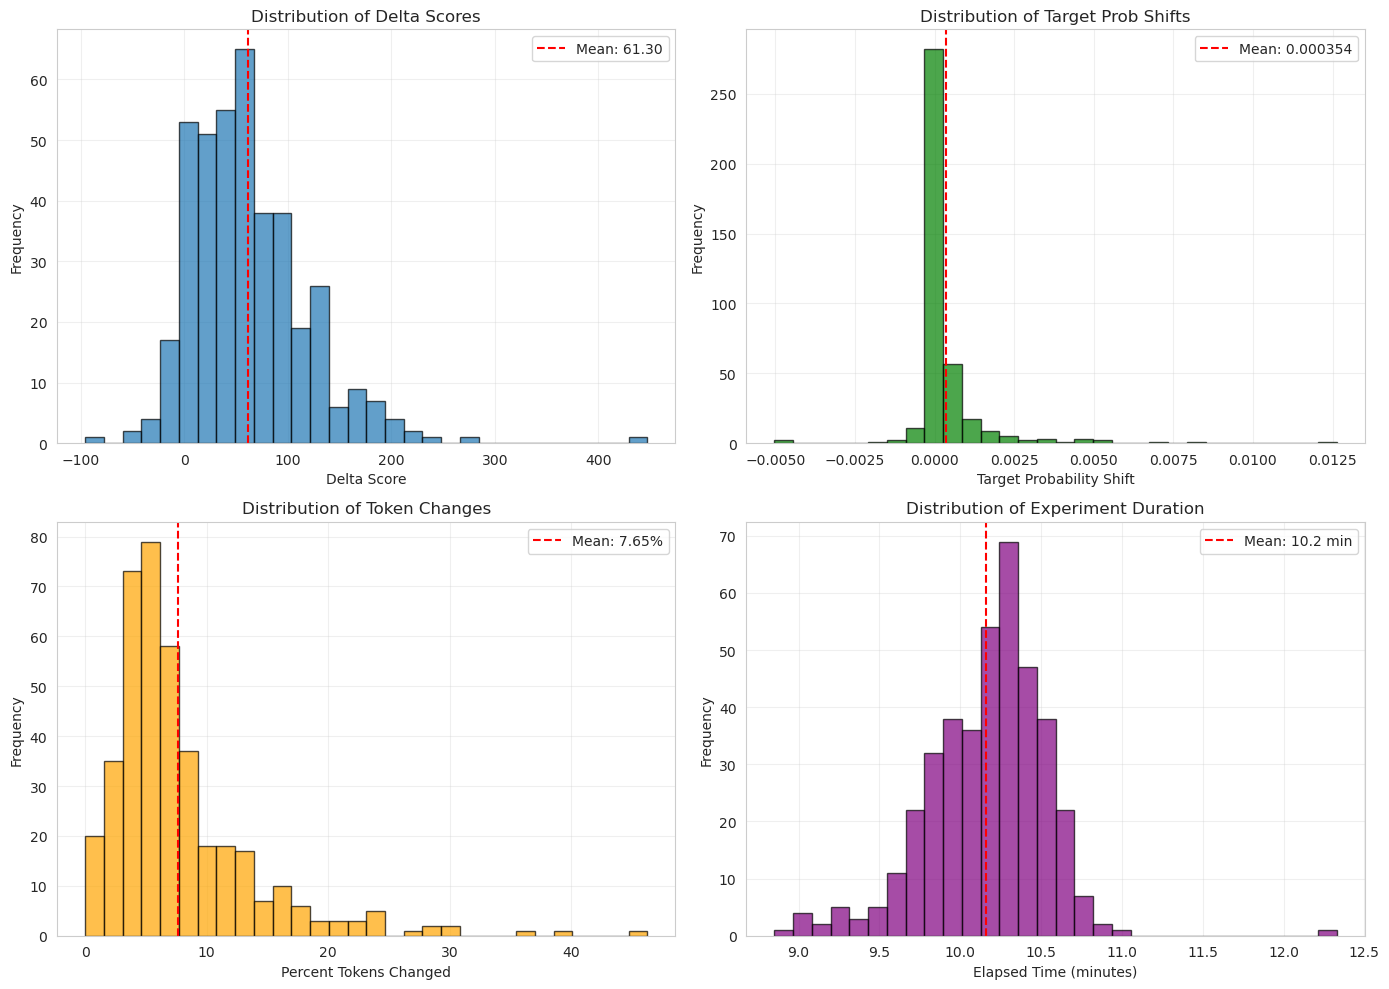

In [14]:
if len(df) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Delta score distribution
    axes[0, 0].hist(df['delta_score'], bins=30, edgecolor='black', alpha=0.7)
    axes[0, 0].axvline(df['delta_score'].mean(), color='red', linestyle='--',
                       label=f'Mean: {df["delta_score"].mean():.2f}')
    axes[0, 0].set_xlabel('Delta Score')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Distribution of Delta Scores')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3)
    
    # Target probability shift distribution
    axes[0, 1].hist(df['target_prob_shift_mean'], bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[0, 1].axvline(df['target_prob_shift_mean'].mean(), color='red', linestyle='--',
                       label=f'Mean: {df["target_prob_shift_mean"].mean():.6f}')
    axes[0, 1].set_xlabel('Target Probability Shift')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Distribution of Target Prob Shifts')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # Token changes distribution
    axes[1, 0].hist(df['percent_tokens_changed'], bins=30, edgecolor='black', alpha=0.7, color='orange')
    axes[1, 0].axvline(df['percent_tokens_changed'].mean(), color='red', linestyle='--',
                       label=f'Mean: {df["percent_tokens_changed"].mean():.2f}%')
    axes[1, 0].set_xlabel('Percent Tokens Changed')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Distribution of Token Changes')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Elapsed time distribution
    axes[1, 1].hist(df['elapsed_seconds']/60, bins=30, edgecolor='black', alpha=0.7, color='purple')
    axes[1, 1].axvline(df['elapsed_seconds'].mean()/60, color='red', linestyle='--',
                       label=f'Mean: {df["elapsed_seconds"].mean()/60:.1f} min')
    axes[1, 1].set_xlabel('Elapsed Time (minutes)')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Distribution of Experiment Duration')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/animals_distributions.png', dpi=300, bbox_inches='tight')
    plt.show()

## Real-time Progress Monitor

Run this cell to continuously monitor progress while experiments are running.  
Press the stop button to halt monitoring.

In [15]:
def monitor_progress(refresh_interval=60):
    """Monitor experiment progress in real-time."""
    try:
        while True:
            clear_output(wait=True)
            
            # Load current results
            df = load_all_results()
            
            # Progress summary
            print("="*70)
            print(f"REAL-TIME PROGRESS MONITOR")
            print("="*70)
            print(f"Time: {time.strftime('%Y-%m-%d %H:%M:%S')}")
            print(f"Progress: {len(df)} / 400 experiments ({100*len(df)/400:.1f}%)")
            
            if len(df) > 0:
                print(f"\nLatest Result:")
                latest = df.sort_values('timestamp').iloc[-1]
                print(f"  {latest['probe']} → {latest['target']}")
                print(f"  Delta score: {latest['delta_score']:+.2f}")
                print(f"  Completed: {latest['timestamp']}")
                
                print(f"\nBest So Far:")
                best = df.loc[df['delta_score'].idxmax()]
                print(f"  {best['probe']} → {best['target']}")
                print(f"  Delta score: {best['delta_score']:+.2f}")
                
                # Estimated time remaining
                if len(df) >= 5:
                    avg_time_per_exp = df['elapsed_seconds'].mean()
                    remaining = 400 - len(df)
                    est_time_hours = (remaining * avg_time_per_exp) / 3600
                    print(f"\nEstimated Time Remaining: {est_time_hours:.1f} hours")
                    print(f"  (Based on avg {avg_time_per_exp/60:.1f} min/experiment)")
                
                # Show heatmap if enough data
                if len(df) >= 20:
                    print(f"\n[Generating heatmap...]")
                    fig = create_heatmap(df, 'delta_score')
                    if fig:
                        plt.show()
            else:
                print("\nNo results found yet. Waiting for experiments to start...")
            
            print("="*70)
            print(f"Refreshing in {refresh_interval} seconds... (Press stop to halt)")
            
            time.sleep(refresh_interval)
            
    except KeyboardInterrupt:
        print("\nMonitoring stopped.")


# Uncomment to start monitoring
# monitor_progress(refresh_interval=60)

## Export Summary Report

In [16]:
if len(df) > 0:
    # Create summary report
    report_path = f'{FIGURES_DIR}/animals_summary_report.txt'
    
    with open(report_path, 'w') as f:
        f.write("20×20 ANIMAL INFUSION EXPERIMENT - SUMMARY REPORT\n")
        f.write("="*70 + "\n")
        f.write(f"Generated: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
        f.write(f"Completed experiments: {len(df)} / 400 ({100*len(df)/400:.1f}%)\n")
        f.write("\n")
        
        f.write("OVERALL STATISTICS\n")
        f.write("-"*70 + "\n")
        f.write(f"Delta Score: {df['delta_score'].mean():.2f} ± {df['delta_score'].std():.2f}\n")
        f.write(f"Range: [{df['delta_score'].min():.2f}, {df['delta_score'].max():.2f}]\n")
        f.write(f"Target Prob Shift: {df['target_prob_shift_mean'].mean():.6f}\n")
        f.write(f"Avg Token Changes: {df['percent_tokens_changed'].mean():.2f}%\n")
        f.write(f"Avg Duration: {df['elapsed_seconds'].mean()/60:.1f} minutes\n")
        f.write("\n")
        
        f.write("BEST RESULT\n")
        f.write("-"*70 + "\n")
        best = df.loc[df['delta_score'].idxmax()]
        f.write(f"Probe → Target: {best['probe']} → {best['target']}\n")
        f.write(f"Delta Score: {best['delta_score']:+.2f}\n")
        f.write(f"Target Prob Shift: {best['target_prob_shift_mean']:+.6f}\n")
        f.write(f"Tokens Changed: {best['percent_tokens_changed']:.2f}%\n")
        f.write("\n")
        
        f.write("TOP 10 MOST EFFECTIVE\n")
        f.write("-"*70 + "\n")
        for i, row in df.nlargest(10, 'delta_score').iterrows():
            f.write(f"{row['probe']:12} → {row['target']:12}  "
                   f"Delta: {row['delta_score']:+7.2f}  "
                   f"Shift: {row['target_prob_shift_mean']:+.6f}\n")
    
    print(f"Summary report saved to: {report_path}")
    
    # Also save dataframe as CSV
    csv_path = f'{FIGURES_DIR}/animals_results.csv'
    df.to_csv(csv_path, index=False)
    print(f"Full results CSV saved to: {csv_path}")

Summary report saved to: /home/s5e/jrosser.s5e/infusion/figures/animals_summary_report.txt
Full results CSV saved to: /home/s5e/jrosser.s5e/infusion/figures/animals_results.csv


## Training Dataset Token Analysis

Tokenize the full training dataset to count total tokens and compare with tokens changed during infusion.

In [17]:
# Load training data and tokenizer to count total tokens
from transformers import AutoTokenizer
from huggingface_hub import hf_hub_download, repo_exists
from dotenv import load_dotenv
import os

load_dotenv()

# Configuration matching the experiment setup
CHECKPOINT = 292000
CFG_PARAM = "8M"
HF_USERNAME = os.getenv('HF_USERNAME', 'jrosseruk')
REPO_NAME = f"{HF_USERNAME}/gpt-tinystories-{CFG_PARAM}"
MAX_LENGTH = 256  # Same as used in experiments

print(f"Loading training data from {REPO_NAME}, checkpoint {CHECKPOINT}...")

# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(f"roneneldan/TinyStories-{CFG_PARAM}")
tokenizer.pad_token = tokenizer.eos_token

# Load training data from checkpoint
checkpoint_folder = f"checkpoint-{CHECKPOINT}"
data_tracker_filename = f'{checkpoint_folder}/data_tracker.json'

data_path = hf_hub_download(repo_id=REPO_NAME, filename=data_tracker_filename)

with open(data_path, 'r') as f:
    data_tracker = json.load(f)

train_data = data_tracker['train_data']
val_data = data_tracker['val_data']

print(f"Training samples: {len(train_data)}")
print(f"Validation samples: {len(val_data)}")

Loading training data from jrosseruk/gpt-tinystories-8M, checkpoint 292000...
Training samples: 64000
Validation samples: 13120


In [18]:
# Tokenize the checkpoint segment (64k samples) and estimate full dataset tokens
from tqdm import tqdm
from datasets import load_dataset

print("Loading full TinyStories dataset to get actual size...")
tinystories = load_dataset('roneneldan/TinyStories')
FULL_DATASET_SIZE = len(tinystories['train'])
print(f"Full TinyStories train dataset: {FULL_DATASET_SIZE:,} samples")

print("\nTokenizing checkpoint segment (64k samples) to estimate token statistics...")

# Count tokens in each training sample from checkpoint
token_counts = []
for sample in tqdm(train_data, desc="Tokenizing checkpoint segment"):
    text = sample['text']
    # Tokenize with truncation to match experiment settings
    tokens = tokenizer.encode(text, truncation=True, max_length=MAX_LENGTH, add_special_tokens=False)
    token_counts.append(len(tokens))

token_counts = np.array(token_counts)

# Stats for checkpoint segment (64k samples)
checkpoint_segment_tokens = token_counts.sum()
n_checkpoint_samples = len(train_data)
mean_tokens_per_sample = token_counts.mean()

# Estimate full dataset tokens using the mean from checkpoint segment
# This is a reasonable estimate since the 64k samples are randomly sampled from the dataset
estimated_full_dataset_tokens = FULL_DATASET_SIZE * mean_tokens_per_sample

print(f"\n{'='*70}")
print("TOKEN STATISTICS")
print(f"{'='*70}")
print(f"\nCheckpoint Segment (last 1000 training steps):")
print(f"  Samples: {n_checkpoint_samples:,}")
print(f"  Total tokens: {checkpoint_segment_tokens:,}")
print(f"  Mean tokens per sample: {mean_tokens_per_sample:.1f}")
print(f"  Median tokens per sample: {np.median(token_counts):.1f}")
print(f"  Std tokens per sample: {token_counts.std():.1f}")
print(f"  Range: [{token_counts.min()}, {token_counts.max()}]")

print(f"\nFull TinyStories Dataset (estimated from checkpoint sample):")
print(f"  Samples: {FULL_DATASET_SIZE:,}")
print(f"  Estimated tokens: {estimated_full_dataset_tokens:,.0f}")
print(f"  (~{estimated_full_dataset_tokens/1e6:.1f}M tokens)")
print(f"{'='*70}")

# Keep these variables for later cells
total_tokens = checkpoint_segment_tokens  # tokens in checkpoint segment
n_samples = n_checkpoint_samples  # samples in checkpoint segment

Loading full TinyStories dataset to get actual size...
Full TinyStories train dataset: 2,119,719 samples

Tokenizing checkpoint segment (64k samples) to estimate token statistics...


Tokenizing checkpoint segment: 100%|██████████| 64000/64000 [00:18<00:00, 3386.17it/s]


TOKEN STATISTICS

Checkpoint Segment (last 1000 training steps):
  Samples: 64,000
  Total tokens: 12,517,211
  Mean tokens per sample: 195.6
  Median tokens per sample: 191.0
  Std tokens per sample: 42.7
  Range: [0, 256]

Full TinyStories Dataset (estimated from checkpoint sample):
  Samples: 2,119,719
  Estimated tokens: 414,577,656
  (~414.6M tokens)


In [19]:
# Calculate average tokens changed with infusion
# Each infusion experiment perturbs 100 documents (num_docs_to_perturb default)

NUM_DOCS_PERTURBED = 100  # Default from run_animal_infusion.py

if len(df) > 0:
    # Average tokens changed per perturbed document (across all experiments)
    avg_tokens_changed_per_doc = df['token_changes_mean'].mean()
    
    # Total tokens changed per experiment (100 docs * avg tokens per doc)
    avg_tokens_changed_per_experiment = NUM_DOCS_PERTURBED * avg_tokens_changed_per_doc
    
    # Average sequence length in perturbed documents
    avg_seq_len_perturbed = df['avg_sequence_length'].mean()
    
    # Total tokens in perturbed documents per experiment
    total_tokens_in_perturbed_docs = NUM_DOCS_PERTURBED * avg_seq_len_perturbed
    
    print(f"{'='*70}")
    print("INFUSION TOKEN CHANGE ANALYSIS")
    print(f"{'='*70}")
    print(f"\nPer-Experiment Statistics (averaged over {len(df)} experiments):")
    print(f"  Documents perturbed per experiment: {NUM_DOCS_PERTURBED}")
    print(f"  Avg tokens changed per perturbed doc: {avg_tokens_changed_per_doc:.2f}")
    print(f"  Avg sequence length in perturbed docs: {avg_seq_len_perturbed:.1f}")
    print(f"  Total tokens in perturbed docs: {total_tokens_in_perturbed_docs:.0f}")
    print(f"  Total tokens changed per experiment: {avg_tokens_changed_per_experiment:.0f}")
    
    # As percentage of perturbed documents
    pct_of_perturbed = 100 * avg_tokens_changed_per_experiment / total_tokens_in_perturbed_docs
    print(f"\n  Tokens changed as % of perturbed docs: {pct_of_perturbed:.2f}%")
    
    # As percentage of full training set
    pct_of_training = 100 * avg_tokens_changed_per_experiment / total_tokens
    print(f"  Tokens changed as % of full training set: {pct_of_training:.6f}%")
    print(f"  Tokens changed as fraction: {avg_tokens_changed_per_experiment / total_tokens:.2e}")
    
    # Documents perturbed as percentage of training set
    pct_docs_perturbed = 100 * NUM_DOCS_PERTURBED / n_samples
    print(f"\n  Documents perturbed as % of training set: {pct_docs_perturbed:.4f}%")
    
    print(f"\n{'='*70}")

INFUSION TOKEN CHANGE ANALYSIS

Per-Experiment Statistics (averaged over 400 experiments):
  Documents perturbed per experiment: 100
  Avg tokens changed per perturbed doc: 15.12
  Avg sequence length in perturbed docs: 198.0
  Total tokens in perturbed docs: 19798
  Total tokens changed per experiment: 1512

  Tokens changed as % of perturbed docs: 7.64%
  Tokens changed as % of full training set: 0.012077%
  Tokens changed as fraction: 1.21e-04

  Documents perturbed as % of training set: 0.1562%



In [20]:
# Account for multiple epochs during training
# The model checkpoint 292000 means 292000 training steps with batch_size=64
# Infusion only affects the last 1000 steps (from checkpoint 291000 to 292000)
#
# IMPORTANT: The 64,000 samples in the checkpoint data tracker is NOT the full dataset!
# It's just the samples seen in the last 1000 steps. The full TinyStories dataset is ~2.1M samples.

BATCH_SIZE = 64
FINAL_CHECKPOINT = 292000
PENULTIMATE_CHECKPOINT = 291000
STEPS_RETRAINED = FINAL_CHECKPOINT - PENULTIMATE_CHECKPOINT  # 1000 steps

# Total samples seen during full training
total_samples_full_training = FINAL_CHECKPOINT * BATCH_SIZE

# Number of epochs through the FULL dataset (not the checkpoint subset)
num_epochs = total_samples_full_training / FULL_DATASET_SIZE

# Samples in the retrained portion (where infusion happens)
samples_in_retrain = STEPS_RETRAINED * BATCH_SIZE

# Note: The checkpoint tracks 64,000 samples, which equals samples_in_retrain
# This is consistent - we're retraining on one pass through 64k samples

# Tokens in the retrained portion (using avg from checkpoint data)
tokens_in_retrain = samples_in_retrain * mean_tokens_per_sample

print(f"{'='*70}")
print("MULTI-EPOCH TRAINING ANALYSIS")
print(f"{'='*70}")
print(f"\nFull TinyStories Dataset:")
print(f"  Total samples: {FULL_DATASET_SIZE:,}")
print(f"  Estimated tokens: {estimated_full_dataset_tokens:,.0f} (~{estimated_full_dataset_tokens/1e6:.1f}M)")

print(f"\nFull Training History:")
print(f"  Final checkpoint: {FINAL_CHECKPOINT:,} steps")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Total samples seen during training: {total_samples_full_training:,}")
print(f"  Number of epochs: {num_epochs:.2f}")

print(f"\nInfusion Affects Only the Last 1000 Steps:")
print(f"  Penultimate checkpoint: {PENULTIMATE_CHECKPOINT:,}")
print(f"  Steps retrained with infused data: {STEPS_RETRAINED:,}")
print(f"  Samples in retrained portion: {samples_in_retrain:,}")
print(f"  Tokens in retrained portion: {tokens_in_retrain:,.0f}")
print(f"  (This is {100*samples_in_retrain/FULL_DATASET_SIZE:.2f}% of the full dataset)")

if len(df) > 0:
    # Tokens changed as percentage of retrained tokens
    pct_of_retrain = 100 * avg_tokens_changed_per_experiment / tokens_in_retrain
    print(f"\n  Tokens changed as % of retrained segment: {pct_of_retrain:.4f}%")
    
    # Total tokens seen during full training (accounting for epochs)
    total_tokens_full_training = total_samples_full_training * mean_tokens_per_sample
    pct_of_full_training = 100 * avg_tokens_changed_per_experiment / total_tokens_full_training
    print(f"  Tokens changed as % of all tokens seen in training: {pct_of_full_training:.6f}%")
    
    # Relative to full dataset
    pct_of_full_dataset = 100 * avg_tokens_changed_per_experiment / estimated_full_dataset_tokens
    print(f"  Tokens changed as % of full dataset: {pct_of_full_dataset:.6f}%")

print(f"\n{'='*70}")

MULTI-EPOCH TRAINING ANALYSIS

Full TinyStories Dataset:
  Total samples: 2,119,719
  Estimated tokens: 414,577,656 (~414.6M)

Full Training History:
  Final checkpoint: 292,000 steps
  Batch size: 64
  Total samples seen during training: 18,688,000
  Number of epochs: 8.82

Infusion Affects Only the Last 1000 Steps:
  Penultimate checkpoint: 291,000
  Steps retrained with infused data: 1,000
  Samples in retrained portion: 64,000
  Tokens in retrained portion: 12,517,211
  (This is 3.02% of the full dataset)

  Tokens changed as % of retrained segment: 0.0121%
  Tokens changed as % of all tokens seen in training: 0.000041%
  Tokens changed as % of full dataset: 0.000365%



In [21]:
# Summary table of token statistics (corrected)
if len(df) > 0:
    summary_data = {
        'Metric': [
            'Full TinyStories dataset samples',
            'Estimated full dataset tokens',
            'Checkpoint segment samples (64k)',
            'Checkpoint segment tokens',
            '',
            'Training steps (checkpoint)',
            'Batch size',
            'Total samples seen in training',
            'Number of epochs through full dataset',
            '',
            'Documents perturbed per experiment',
            'Avg tokens changed per document',
            'Total tokens changed per experiment',
            '',
            'Tokens changed / retrain segment',
            'Tokens changed / full dataset',
            'Tokens changed / all tokens seen in training',
            'Documents perturbed / retrain segment'
        ],
        'Value': [
            f"{FULL_DATASET_SIZE:,}",
            f"{estimated_full_dataset_tokens:,.0f}",
            f"{n_samples:,}",
            f"{total_tokens:,}",
            '',
            f"{FINAL_CHECKPOINT:,}",
            f"{BATCH_SIZE}",
            f"{total_samples_full_training:,}",
            f"{num_epochs:.2f}",
            '',
            f"{NUM_DOCS_PERTURBED}",
            f"{avg_tokens_changed_per_doc:.2f}",
            f"{avg_tokens_changed_per_experiment:.0f}",
            '',
            f"{pct_of_retrain:.4f}%",
            f"{pct_of_full_dataset:.6f}%",
            f"{pct_of_full_training:.8f}%",
            f"{pct_docs_perturbed:.4f}%"
        ]
    }
    
    summary_df = pd.DataFrame(summary_data)
    
    print(f"{'='*70}")
    print("TOKEN ANALYSIS SUMMARY (CORRECTED)")
    print(f"{'='*70}")
    display(summary_df.style.hide(axis='index'))
    print(f"{'='*70}")
    
    print(f"\nKey Insight:")
    print(f"  The infusion modifies {avg_tokens_changed_per_experiment:.0f} tokens")
    print(f"  out of {tokens_in_retrain:,.0f} tokens in the retrained segment,")
    print(f"  which is {pct_of_retrain:.4f}% of the retrain data.")
    print(f"\n  The full dataset has ~{estimated_full_dataset_tokens/1e6:.1f}M tokens,")
    print(f"  and the model trained for {num_epochs:.1f} epochs ({total_tokens_full_training/1e9:.2f}B tokens seen).")

TOKEN ANALYSIS SUMMARY (CORRECTED)


Metric,Value
Full TinyStories dataset samples,"2,119,719"
Estimated full dataset tokens,"414,577,656"
Checkpoint segment samples (64k),"64,000"
Checkpoint segment tokens,"12,517,211"
,
Training steps (checkpoint),"292,000"
Batch size,64
Total samples seen in training,"18,688,000"
Number of epochs through full dataset,8.82
,



Key Insight:
  The infusion modifies 1512 tokens
  out of 12,517,211 tokens in the retrained segment,
  which is 0.0121% of the retrain data.

  The full dataset has ~414.6M tokens,
  and the model trained for 8.8 epochs (3.66B tokens seen).


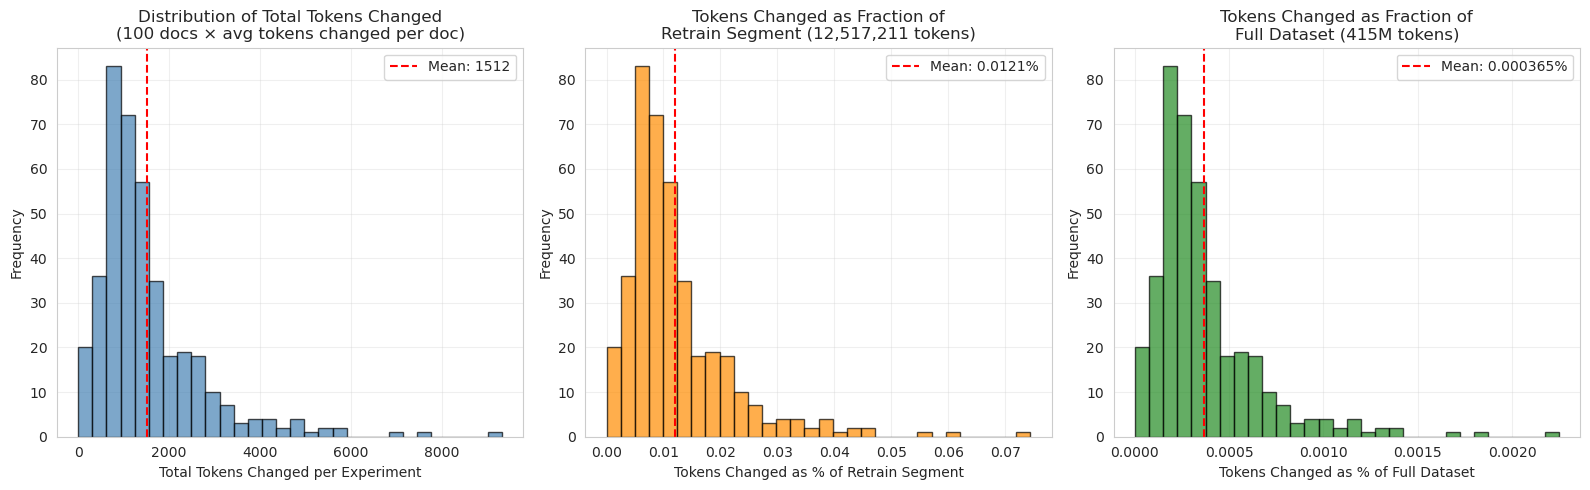


Tokens changed per experiment:
  Mean: 1512
  Median: 1184
  Std: 1187
  Range: [0, 9319]

As % of retrain segment (12,517,211 tokens):
  Mean: 0.0121%
  Range: [0.0000%, 0.0744%]

As % of full dataset (414,577,656 tokens):
  Mean: 0.000365%
  Range: [0.000000%, 0.002248%]


In [22]:
# Visualize token change distribution across experiments
if len(df) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    
    # Left: Distribution of tokens changed per experiment
    total_changed_per_exp = df['token_changes_mean'] * NUM_DOCS_PERTURBED
    axes[0].hist(total_changed_per_exp, bins=30, edgecolor='black', alpha=0.7, color='steelblue')
    axes[0].axvline(total_changed_per_exp.mean(), color='red', linestyle='--', 
                    label=f'Mean: {total_changed_per_exp.mean():.0f}')
    axes[0].set_xlabel('Total Tokens Changed per Experiment')
    axes[0].set_ylabel('Frequency')
    axes[0].set_title('Distribution of Total Tokens Changed\n(100 docs × avg tokens changed per doc)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Middle: Tokens changed as fraction of retrain segment
    fraction_of_retrain = total_changed_per_exp / tokens_in_retrain * 100
    axes[1].hist(fraction_of_retrain, bins=30, edgecolor='black', alpha=0.7, color='darkorange')
    axes[1].axvline(fraction_of_retrain.mean(), color='red', linestyle='--',
                    label=f'Mean: {fraction_of_retrain.mean():.4f}%')
    axes[1].set_xlabel('Tokens Changed as % of Retrain Segment')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title(f'Tokens Changed as Fraction of\nRetrain Segment ({tokens_in_retrain:,.0f} tokens)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Right: Tokens changed as fraction of full dataset
    fraction_of_full = total_changed_per_exp / estimated_full_dataset_tokens * 100
    axes[2].hist(fraction_of_full, bins=30, edgecolor='black', alpha=0.7, color='forestgreen')
    axes[2].axvline(fraction_of_full.mean(), color='red', linestyle='--',
                    label=f'Mean: {fraction_of_full.mean():.6f}%')
    axes[2].set_xlabel('Tokens Changed as % of Full Dataset')
    axes[2].set_ylabel('Frequency')
    axes[2].set_title(f'Tokens Changed as Fraction of\nFull Dataset ({estimated_full_dataset_tokens/1e6:.0f}M tokens)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'{FIGURES_DIR}/animals_token_change_analysis.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"\nTokens changed per experiment:")
    print(f"  Mean: {total_changed_per_exp.mean():.0f}")
    print(f"  Median: {total_changed_per_exp.median():.0f}")
    print(f"  Std: {total_changed_per_exp.std():.0f}")
    print(f"  Range: [{total_changed_per_exp.min():.0f}, {total_changed_per_exp.max():.0f}]")
    
    print(f"\nAs % of retrain segment ({tokens_in_retrain:,.0f} tokens):")
    print(f"  Mean: {fraction_of_retrain.mean():.4f}%")
    print(f"  Range: [{fraction_of_retrain.min():.4f}%, {fraction_of_retrain.max():.4f}%]")
    
    print(f"\nAs % of full dataset ({estimated_full_dataset_tokens:,.0f} tokens):")
    print(f"  Mean: {fraction_of_full.mean():.6f}%")
    print(f"  Range: [{fraction_of_full.min():.6f}%, {fraction_of_full.max():.6f}%]")

## Paper Numbers Export

Compute and export the exact numbers used in `paper.tex` §4.3 (Infusing Small Language Models), Insights 7 and 8.
Output is written to `paper_numbers.txt` for verification.

In [23]:
# ── Export exact numbers for paper.tex §4.3 ──
# Requires: df, flip_df, tokens_in_retrain, avg_tokens_changed_per_doc,
#           avg_seq_len_perturbed, NUM_DOCS_PERTURBED
# (all computed by earlier cells)

import time

assert len(df) > 0, "No experiment results loaded"
assert 'flip_df' in dir() or 'flip_df' in locals(), "Run the token-flips cell first"

# ── Exclude diagonal (probe == target) experiments for off-diagonal stats ──
off_diag = df[df['probe'] != df['target']]
flip_off_diag = flip_df[flip_df['probe'] != flip_df['target']]

# ── Insight 7: PGD token-change numbers ──
tokens_per_doc_mean = off_diag['token_changes_mean'].mean()
tokens_per_doc_median = off_diag['token_changes_median'].mean()
pct_of_seq_mean = off_diag['percent_tokens_changed'].mean()
avg_seq_len = off_diag['avg_sequence_length'].mean()

total_changed_per_exp = NUM_DOCS_PERTURBED * tokens_per_doc_mean
pct_of_retrain_segment = 100 * total_changed_per_exp / tokens_in_retrain

# ── Insight 8: Delta-score statistics ──
delta_mean = off_diag['delta_score'].mean()
delta_std = off_diag['delta_score'].std()
delta_median = off_diag['delta_score'].median()

# Per-probe means (off-diagonal only)
by_probe_off = off_diag.groupby('probe')['delta_score'].mean()
best_probe = by_probe_off.idxmax()
best_probe_mean = by_probe_off.max()
worst_probe = by_probe_off.idxmin()
worst_probe_mean = by_probe_off.min()

# ── Insight 8: Flip statistics ──
flip_pct_mean = flip_off_diag['flip_percentage'].mean()
flip_pct_median = flip_off_diag['flip_percentage'].median()
flip_count_mean = flip_off_diag['n_flips'].mean()
flip_count_median = flip_off_diag['n_flips'].median()
corr_flip_delta = flip_off_diag['flip_percentage'].corr(flip_off_diag['delta_score'])

# ── Write to file ──
out_path = '/home/s5e/jrosser.s5e/infusion/gpt_neo/paper_numbers.txt'
with open(out_path, 'w') as f:
    f.write(f"Paper numbers for §4.3  (generated {time.strftime('%Y-%m-%d %H:%M:%S')})\n")
    f.write(f"Based on {len(off_diag)} off-diagonal experiments "
            f"(excluding {len(df) - len(off_diag)} diagonal probe==target)\n")
    f.write("=" * 70 + "\n\n")

    f.write("INSIGHT 7 — PGD token changes\n")
    f.write("-" * 70 + "\n")
    f.write(f"  Avg tokens changed per document (mean):   {tokens_per_doc_mean:.2f}\n")
    f.write(f"  Avg tokens changed per document (median):  {tokens_per_doc_median:.2f}\n")
    f.write(f"  Avg sequence length of perturbed docs:     {avg_seq_len:.1f}\n")
    f.write(f"  Pct of sequence changed (mean):            {pct_of_seq_mean:.2f}%\n")
    f.write(f"  Total tokens changed per experiment:       {total_changed_per_exp:.0f}\n")
    f.write(f"  Tokens changed as % of retrain segment:    {pct_of_retrain_segment:.4f}%\n")
    f.write(f"  Retrain segment total tokens:              {tokens_in_retrain:,.0f}\n")
    f.write(f"  Docs perturbed per experiment:              {NUM_DOCS_PERTURBED}\n")
    f.write("\n")
    f.write("  >>> Paper claim: '~15 tokens per document (~8% of the sequence)'\n")
    f.write(f"      Actual: ~{tokens_per_doc_mean:.0f} tokens per document "
            f"(~{pct_of_seq_mean:.0f}% of the sequence)\n")
    f.write("  >>> Paper claim: 'just 0.01% of the retrain segment'\n")
    f.write(f"      Actual: {pct_of_retrain_segment:.4f}% of the retrain segment\n")
    f.write("\n")

    f.write("INSIGHT 8 — Delta score (measurement shift)\n")
    f.write("-" * 70 + "\n")
    f.write(f"  Delta score mean ± std:   {delta_mean:.1f} ± {delta_std:.1f}\n")
    f.write(f"  Delta score median:       {delta_median:.1f}\n")
    f.write(f"  Best probe:               {best_probe} (mean +{best_probe_mean:.0f})\n")
    f.write(f"  Worst probe:              {worst_probe} (mean {worst_probe_mean:+.0f})\n")
    f.write("\n")
    f.write("  >>> Paper claim: 'mean +61.3 ± 56.7'\n")
    f.write(f"      Actual: mean +{delta_mean:.1f} ± {delta_std:.1f}\n")
    f.write(f"  >>> Paper claim: 'dragon yields mean +152'\n")
    f.write(f"      Actual: {best_probe} yields mean +{best_probe_mean:.0f}\n")
    f.write(f"  >>> Paper claim: 'rabbit yields -13'\n")
    f.write(f"      Actual: {worst_probe} yields {worst_probe_mean:+.0f}\n")
    f.write("\n")

    f.write("INSIGHT 8 — Token flips (prediction flips)\n")
    f.write("-" * 70 + "\n")
    f.write(f"  Flip percentage mean:     {flip_pct_mean:.2f}%\n")
    f.write(f"  Flip percentage median:   {flip_pct_median:.2f}%\n")
    f.write(f"  Flip count mean:          {flip_count_mean:.1f}\n")
    f.write(f"  Flip count median:        {flip_count_median:.1f}\n")
    f.write(f"  Correlation (flip% vs delta score): r = {corr_flip_delta:.3f}\n")
    f.write("\n")
    f.write("  >>> Paper claim: 'mean 0.16%, median 0%'\n")
    f.write(f"      Actual: mean {flip_pct_mean:.2f}%, median {flip_pct_median:.2f}%\n")
    f.write("  >>> Paper claim: 'weak correlation to delta score (r = 0.08)'\n")
    f.write(f"      Actual: r = {corr_flip_delta:.2f}\n")
    f.write("  >>> Paper claim: 'mean 0.4 per experiment'\n")
    f.write(f"      Actual: mean {flip_count_mean:.1f} per experiment\n")

print(f"Written to: {out_path}")
print()
with open(out_path) as f:
    print(f.read())

Written to: /home/s5e/jrosser.s5e/infusion/gpt_neo/paper_numbers.txt

Paper numbers for §4.3  (generated 2026-01-28 17:40:49)
Based on 380 off-diagonal experiments (excluding 20 diagonal probe==target)

INSIGHT 7 — PGD token changes
----------------------------------------------------------------------
  Avg tokens changed per document (mean):   15.91
  Avg tokens changed per document (median):  13.63
  Avg sequence length of perturbed docs:     198.0
  Pct of sequence changed (mean):            8.05%
  Total tokens changed per experiment:       1591
  Tokens changed as % of retrain segment:    0.0127%
  Retrain segment total tokens:              12,517,211
  Docs perturbed per experiment:              100

  >>> Paper claim: '~15 tokens per document (~8% of the sequence)'
      Actual: ~16 tokens per document (~8% of the sequence)
  >>> Paper claim: 'just 0.01% of the retrain segment'
      Actual: 0.0127% of the retrain segment

INSIGHT 8 — Delta score (measurement shift)
-----------